# Project Introduction [sentiment]

## Project Overview
This notebook implements an end-to-end machine learning workflow for **sentiment analysis from tweets**. It unifies data preparation, exploratory analysis, classical baselines, static-embedding neural models, and transformer fine-tuning in a single reproducible experiment pipeline.

The dataset is structured around two primary data fields: a text feature containing string data and a label feature for multi-class emotion classification. This label categorizes entries into seven distinct emotional states: sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5), and neutral (6). The dataset has 416,809 observations contained within a single training split.

## Objectives
- Establish reliable baselines and progressively stronger models under a shared train/validation/test protocol.
- Compare model families consistently using accuracy, macro/weighted F1, confusion matrices, and learning curves.
- Track experiment outputs (checkpoints, logs, plots, metrics) for reproducible analysis and reporting.
- Provide one configurable notebook for both full reruns and targeted experimentation.

## Table of Contents
- [SECTION 0 — Environment Setup & Reproducibility](#section-0-environment-setup-reproducibility)
- [SECTION 1 — Utility Functions & Helper Classes](#section-1-utility-functions-helper-classes)
    - [1.1 Core Constants & Plot Display Helper](#11-core-constants-plot-display-helper)
    - [1.2 Text Preprocessing Helpers](#12-text-preprocessing-helpers)
    - [1.3 EDA Text Feature Helpers](#13-eda-text-feature-helpers)
    - [1.4 Evaluation, I/O, Splitting, and Model Utilities](#14-evaluation-i-o-splitting-and-model-utilities)
    - [1.5 Embedding & Sequence Utilities](#15-embedding-sequence-utilities)
    - [1.6 Deep Experiment Runner Utilities](#16-deep-experiment-runner-utilities)
    - [1.7 Transformer Utilities](#17-transformer-utilities)
    - [1.8 Training Utilities (Shared Deep Learning Loop)](#18-training-utilities-shared-deep-learning-loop)
    - [1.9 Utility Registry Summary](#19-utility-registry-summary)
- [SECTION 2 — Data Loading & Inspection](#section-2-data-loading-inspection)
- [SECTION 3 — Data preparation](#section-3-preprocessing)
  - [Preprocessing steps](#preprocessing-steps)
  - [Train/Val/Test split](#section-3-train-val-test-split)
- [SECTION 5 — Baseline Models](#section-5-baseline-models)
  - [5.1 Preparation & Architecture](#51-preparation-architecture)
  - [5.3 Training](#53-training)
  - [5.4 Results](#54-results)
- [SECTION 6 — Static Embeddings + Models (FastText, MLP + CNN)](#section-6-static-embeddings-fasttext)
  - [6.1 Preparation & Architecture](#61-preparation-architecture)
  - [6.3 Training](#63-training)
  - [6.4 Results](#64-results)
- [SECTION 7 — Recurrent Models (BiLSTM / BiGRU)](#section-7-recurrent-models-bilstm-bigru)
  - [7.1 Preparation & Architecture](#71-preparation-architecture)
  - [7.3 Training](#73-training)
  - [7.4 Results](#74-results)
- [SECTION 11 — Transformer Fine-Tuning](#section-11-transformer-fine-tuning)
  - [11.1 Preparation & Architecture](#111-preparation-architecture)
  - [11.3 Training](#113-training)
    - [11.3.1 DistilBERT_500k](#1131-distilbert-500k)
    - [11.3.2 RoBERTa_500k](#1132-roberta-500k)
    - [11.3.3 DistilBERT_1000k](#1133-distilbert-1000k)
  - [11.4 Results](#114-results)
- [SECTION 12 — Model Comparison & Results Table](#section-12-model-comparison-results-table)
- [SECTION 13 — Saving, Logging & Final Report](#section-13-saving-logging-final-report)

## Notebook Usage Modes
1. **Full pipeline run**
   - Set `CFG["run_data_prep"] = True`, then execute top-to-bottom to rebuild splits and refresh all downstream artifacts.
2. **Evaluation/cached-artifact run**
   - Keep `CFG["run_data_prep"] = False` to reuse stored splits and existing model artifacts.
   - For transformer runs, set `CFG["run_transformer_eval"] = False` to load cached metrics/predictions when available.
3. **Experimentation mode**
   - Modify selected `CFG` entries (for example n-grams, embeddings, model hyperparameters, transformer choice) and rerun only relevant sections.
4. **Transformer-focused run**
   - Run Section 11 once preprocessing/splits are available, then iterate primarily on `trf_model`, `batch_size`, `epochs`, and `lr`.

## Important Notes
- **Dependencies:** The notebook expects the Python ML stack used in Section 0 (`pandas`, `numpy`, `scikit-learn`, `xgboost`, `torch`, `transformers`, `gensim`, `nltk`, `duckdb`, and plotting libraries).
- **NLTK resources:** `stopwords`, `wordnet`, and `punkt` are requested at runtime; ensure internet access on first download.
- **Expected directories:** Inputs and artifacts are organized under `data/`, `models/`, `outputs/`, and `logs/`. Splits are loaded from `data/processed/sentiment/splits.pkl` when preprocessing is skipped.
- **Configuration behavior:** `CFG` in Section 0 is the single execution control point (paths, seed, task metadata, model/training settings, and run toggles).
- **Checkpoint caching:** Deep and transformer routines reuse existing best checkpoints when found and may skip retraining automatically.
- **Reproducibility:** `set_seed(CFG["seed"])` is applied in Section 1; device selection is automatic (`mps`/`cuda`/`cpu`). Keep package versions and hardware consistent for strict run-to-run comparisons.
- **Section numbering:** Section numbering and anchors below are synchronized with the final notebook layout.


---
<a id="section-0-environment-setup-reproducibility"></a>
# SECTION 0 — Environment Setup & Reproducibility


In [97]:
pip install numpy pandas matplotlib seaborn scikit-learn nltk gensim transformers torch accelerate xgboost plotly jupyterlab ipywidgets duckdb

Note: you may need to restart the kernel to use updated packages.


In [98]:
# ── 0.0 Environment Setup & GPU Verification ─────────────────────────────────

!pip install torch --index-url https://download.pytorch.org/whl/cu121
!pip install d2l==1.0.0a1.post0

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: No GPU detected. Check PyTorch.")

Looking in indexes: https://download.pytorch.org/whl/cu121


In [99]:
!pip install torch --index-url https://download.pytorch.org/whl/cu121
!pip install d2l==1.0.0a1.post0

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: No GPU detected. Check PyTorch.")

Looking in indexes: https://download.pytorch.org/whl/cu121


In [100]:
# ── 0.1 Imports ─────────────────────────────────────────────────────────────

# Standard Libraries
import json
import logging
import os
import pickle
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

# Data / Visualization
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# Database
import duckdb

# Sklearn
import joblib
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.svm import LinearSVC

# XGBoost
from xgboost import XGBClassifier

# Deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

# Transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

# Embeddings
import gensim.downloader as api

# NLP (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- Final Configuration ---
nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)

# Avoids parallelism warnings in Hugging Face tokenizers
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("Imports OK") 

Imports OK


In [101]:
# ── 0.2 Global Configuration ─────────────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir":   Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir":  Path("models/"),
    "log_dir":    Path("logs/"),

    # ── Task ────────────────────────────────────────────────────────────────
    # Options: sentiment_analysis | abuse_detection | age-classification | etc.
    "task":       "sentiment_analysis_ao", 
    "text_col":   "text",
    "label_col":  "label",
    "num_labels": 7,

    # ── Notebook execution toggles 
    "run_data_prep": True,
    "run_transformer_eval": True,

    # ── Split
    "test_size": 0.15,
    "val_size":  0.15,

    # ── Cross-validation
    "use_cv":    True,
    "cv_folds":  5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams":   True,
    "class_weight":      "balanced",

    # ── Embeddings 
    "embedding_model": "fasttext-wiki-news-subwords-300", 
    "embedding_dim":   300,
    "vocab_size":      50_000,
    "max_seq_len":     128,
    "pad_token":       "<PAD>",
    "unk_token":       "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs":     20,
    "dl_lr":         1e-3,
    "dl_patience":   3,
    "dropout":       0.3,

    # ── CNN-specific
    "cnn_num_filters":  128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer
    "trf_model":  "bert-base-uncased", # or "distilbert-base-uncased"
    "max_len":    256,
    "batch_size": 16,
    "epochs":     5,
    "lr":         2e-5,

    # ── Device    
    "device": (
        "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
}


CFG["output_paths"] = {
    "eda":              CFG["output_dir"] / "eda",
    "metrics":          CFG["output_dir"] / "metrics",
    "runs":             CFG["output_dir"] / "runs",
    "plots_learning":   CFG["output_dir"] / "plots" / "learning_curves",
    "plots_confusion":  CFG["output_dir"] / "plots" / "confusion_matrices",
    "plots_history":    CFG["output_dir"] / "plots" / "training_curves",
    "plots_comparison": CFG["output_dir"] / "plots" / "comparisons",
}

# ── Directories Setup ─────────────────────────────────────────────────────────
for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)

for p in CFG["output_paths"].values():
    p.mkdir(parents=True, exist_ok=True)

print(f"Task    : {CFG['task']}")
print(f"Labels  : {CFG['num_labels']}")
print(f"Device  : {CFG['device']}")
print(f"Outputs : {CFG['output_dir']} (Subfolders ready)")

Task    : sentiment_analysis_ao
Labels  : 7
Device  : cpu
Outputs : outputs (Subfolders ready)


---
<a id="section-1-utility-functions-helper-classes"></a>
# SECTION 1 — Utility Functions & Helper Classes

We set up the shared helpers before running the experiments. We get one consistent toolkit for preprocessing, training, evaluation, and saving artefacts, so the later sections stay aligned.


<a id="section-1-core-constants-plot-display"></a>
## 1.1 Core Constants, Reproducibility & Plot Display

In [102]:
# ── 1.1 Core constants, reproducibility, and plot display  ─────────────────────────────────────────
CLASSES = ['0', '1', '2', '3', '4', '5', '6']
COLORS = ["#003366", "#0066CC",  "#1171D2", "#4DA6FF", "#99CCFF", "#CCE5FF", "#E2EFFB",]
CUSTOM_PALETTE = ["#E74C3C", "#F39C12", "#F9E04B", "#2ECC71", "#1ABC9C", "#3498DB", "#9B59B6"]

LABEL_NAMES = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
    6: "neutral"
}

sns.set_theme(style="whitegrid", palette=COLORS)
plt.rcParams["figure.dpi"] = 120

def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(CFG["seed"])
print("Seed set.")

def display_saved_plot(plot_path: Path, title: str = None, figsize=(10, 6)) -> bool:
    plot_path = Path(plot_path)
    if not plot_path.exists():
        return False

    try:
        img = plt.imread(plot_path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis("off")
        if title:
            ax.set_title(title)
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"Could not display existing plot {plot_path}: {e}")
        return False


Seed set.


<a id="section-1-text-preprocessing-helpers"></a>
## 1.2 Text Preprocessing Helpers


In [103]:
# ── 1.2 Text preprocessing helpers ─────────────────────────────────────────
STOP = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_from_normalized(text: str, remove_stopwords: bool = True, lemmatize: bool = True) -> str:
    text = text.lower()
    tokens = text.split()
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    return " ".join(tokens)

<a id="section-1-eda-text-feature-helpers"></a>
## 1.3 EDA Text Feature Helpers


In [104]:
# ── 1.3 from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS ─────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

EXTRA_STOPWORDS = globals().get("EXTRA_STOPWORDS", set())
CONSULTING_COLORS = globals().get("CONSULTING_COLORS", COLORS)

def clean_text_fallback(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def get_top_words_tfidf(df, cls, n=15):
    class_texts = {}
    
    temp_df = df.copy()
    temp_df["label"] = temp_df["label"].astype(str)

    for c in CLASSES:
        subset = temp_df[temp_df["label"] == str(c)]["text"]
        texts = subset.dropna().apply(clean_text_fallback).tolist()
        
        combined = " ".join(texts).strip()
        class_texts[str(c)] = combined if len(combined) > 0 else "empty_document_placeholder"

    all_docs = list(class_texts.values())
    all_labels = list(class_texts.keys())

    # TFIDF Vectorizer 
    vec = TfidfVectorizer(
        stop_words=list(ENGLISH_STOP_WORDS.union(EXTRA_STOPWORDS)),
        max_features=10_000,
        ngram_range=(1, 1),
        min_df=1,
    )
    
    try:
        X = vec.fit_transform(all_docs)
        words = vec.get_feature_names_out()

        cls_idx = all_labels.index(str(cls))
        scores = X[cls_idx].toarray().flatten()
        
        if scores.sum() == 0:
            return pd.DataFrame(columns=["word", "score"])

        top = sorted(zip(words, scores), key=lambda x: -x[1])[:n]
        return pd.DataFrame(top, columns=["word", "score"])
    
    except ValueError:
        return pd.DataFrame(columns=["word", "score"])


<a id="section-1-evaluation-splitting-model-utilities"></a>
## 1.4 Evaluation, I/O, Splitting, and Model Utilities


In [105]:
# ── 1.4.1 class DictLabelEncoder: ─────────────────────────────────────────
class DictLabelEncoder:
    def __init__(self, mapping: dict):
        first_key = next(iter(mapping))
        if isinstance(first_key, int):
            id2class = mapping
        else:
            id2class = {v: k for k, v in mapping.items()}
        self.classes_ = np.array([id2class[i] for i in sorted(id2class)])

    def inverse_transform(self, y):
        y_arr = np.asarray(y, dtype=np.int64)
        return np.array([self.classes_[i] if 0 <= i < len(self.classes_) else str(i) for i in y_arr])

    def transform(self, labels):
        class2id = {c: i for i, c in enumerate(self.classes_)}
        labels_arr = np.asarray(labels)
        return np.array([class2id[x] for x in labels_arr], dtype=np.int64)


In [106]:
# ── 1.4.2 RESULTS = {} ─────────────────────────────────────────
RESULTS = {}


def slugify(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")


def now_ts() -> str:
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def size_tag_from_split(split_key: str) -> str:
    m = re.search(r"(\d+[km]?)$", split_key.lower())
    return m.group(1) if m else slugify(split_key)


def first_existing_path(*paths):
    for p in paths:
        if p is None:
            continue
        pp = Path(p)
        if pp.exists():
            return pp
    return None

def load_pickle_with_fallback(primary: Path, *fallbacks: Path):
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find pickle file. Tried: {[str(primary), *map(str, fallbacks)]}")
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"Loaded pickle: {path}")
    return obj

def load_csv_with_fallback(primary: Path, *fallbacks: Path) -> pd.DataFrame:
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find CSV file. Tried: {[str(primary), *map(str, fallbacks)]}")
    print(f"Loaded csv: {path}")
    return pd.read_csv(path)

def display_saved_plot(plot_path: Path, title: str = None, figsize=(10, 6)) -> bool:
    plot_path = Path(plot_path)
    if not plot_path.exists():
        return False

    try:
        img = plt.imread(plot_path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis("off")
        if title:
            ax.set_title(title)
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"Could not display existing plot {plot_path}: {e}")
        return False


def _link_or_copy_file(src: Path, dst: Path):
    src = Path(src)
    dst = Path(dst)
    if dst.exists() or not src.exists() or not src.is_file():
        return
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except Exception:
        shutil.copy2(src, dst)


def _link_or_copy_dir_contents(src_dir: Path, dst_dir: Path, include_pattern: str = None):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    if not src_dir.exists() or not src_dir.is_dir():
        return False

    dst_dir.mkdir(parents=True, exist_ok=True)
    if include_pattern is None:
        items = [p for p in src_dir.iterdir() if p.name != ".DS_Store"]
    else:
        items = [p for p in src_dir.glob(include_pattern)]

    copied_any = False
    for item in items:
        target = dst_dir / item.name
        if target.exists():
            copied_any = True
            continue
        try:
            if item.is_dir():
                os.symlink(item.resolve(), target, target_is_directory=True)
            else:
                os.symlink(item.resolve(), target)
        except Exception:
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)
        copied_any = True

    return copied_any


def find_latest_experiment_dir(prefix: str, model_root: Path = None, require_best: bool = False):
    model_root = model_root or CFG["model_dir"]
    patt = re.compile(rf"^{re.escape(prefix)}_\d{{8}}_\d{{6}}$")
    candidates = [p for p in model_root.iterdir() if p.is_dir() and patt.match(p.name)]
    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda p: p.name)
    if not require_best:
        return candidates[-1]

    for cand in reversed(candidates):
        best_dir = cand / "best_model"
        if best_dir.exists() and any(best_dir.iterdir()):
            return cand
    return None


def resolve_experiment_paths(model_family: str, dataset: str, size_tag: str, model_root: Path = None) -> dict:
    model_root = model_root or CFG["model_dir"]
    prefix = f"{slugify(model_family)}_{slugify(dataset)}_{slugify(size_tag)}"

    exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=True)
    if exp_root is None:
        exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=False)
    if exp_root is None:
        exp_root = model_root / f"{prefix}_{now_ts()}"

    exp_root.mkdir(parents=True, exist_ok=True)
    paths = {
        "prefix": prefix,
        "root": exp_root,
        "best_model": exp_root / "best_model",
        "checkpoints": exp_root / "checkpoints",
        "runs": exp_root / "runs",
    }
    for key in ["best_model", "checkpoints", "runs"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    return paths


def bootstrap_file_from_legacy(dst_path: Path, legacy_candidates=()):
    dst_path = Path(dst_path)
    if dst_path.exists():
        return dst_path

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_file():
            _link_or_copy_file(p, dst_path)
            if dst_path.exists():
                print(f"Linked/copied legacy file: {p} -> {dst_path}")
                break

    return dst_path


def bootstrap_dir_from_legacy(dst_dir: Path, legacy_candidates=(), include_pattern: str = None):
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    if any(dst_dir.iterdir()):
        return dst_dir

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_dir():
            ok = _link_or_copy_dir_contents(p, dst_dir, include_pattern=include_pattern)
            if ok:
                print(f"Bootstrapped legacy dir: {p} -> {dst_dir}")
                break

    return dst_dir


def evaluate_clf(model_name: str, y_true, y_pred,
                 y_prob=None, label_encoder=None, split: str = "test") -> dict:

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc = (roc_auc_score(y_true, y_prob[:, 1]) if (y_prob is not None and y_prob.shape[1] == 2) else None)

    print(f"\n{'='*55}")
    print(f"  {model_name} | {split.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weight:.4f}")
    if auc is not None:
        print(f"  ROC-AUC       : {auc:.4f}")

    if label_encoder is not None:
        class_names = list(label_encoder.classes_)
        labels = np.arange(len(class_names))
        report = classification_report(y_true, y_pred, labels=labels, target_names=class_names, zero_division=0)
    else:
        report = classification_report(y_true, y_pred, zero_division=0)

    print()
    print(report)

    metrics = {"accuracy": float(acc), "f1_macro": float(f1_macro), "f1_weighted": float(f1_weight)}
    if auc is not None:
        metrics["roc_auc"] = float(auc)

    RESULTS[f"{model_name} | {split}"] = metrics
    return metrics


def plot_confusion_matrix_clf(y_true, y_pred, model_name: str, label_encoder=None):
    fname = CFG["output_paths"]["plots_confusion"] / f"cm_{slugify(model_name)}.png"
    if display_saved_plot(fname, title=f"Confusion Matrix — {model_name}", figsize=(13, 5)):
        print(f"Displayed existing confusion matrix: {fname}")
        return

    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_ if label_encoder else np.unique(y_true)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ["Raw Counts", "Normalized"], ["d", ".2f"]
    ):
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap=globals().get("CMAP", "Blues"),
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(title)

    plt.suptitle(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()


def plot_history(history: dict, model_name: str):
    fname = CFG["output_paths"]["plots_history"] / f"history_{slugify(model_name)}.png"
    if display_saved_plot(fname, title=model_name, figsize=(12, 4)):
        print(f"Displayed existing training curve: {fname}")
        return

    if not history or len(history.get("train_loss", [])) == 0:
        print(f"No training history to plot for {model_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train", marker="o", color=COLORS[0])
    axes[0].plot(history["val_loss"], label="Val", marker="o", color=COLORS[2])
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["val_f1_macro"], marker="o", color=COLORS[1])
    axes[1].set_title("Val F1 Macro")
    axes[1].set_xlabel("Epoch")

    plt.suptitle(model_name, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()


def print_results_table():
    if not RESULTS:
        print("RESULTS is empty — run evaluate_clf first.")
        return

    all_cols = sorted({k for v in RESULTS.values() for k in v.keys()})
    header = f"{'Model':<45}" + "".join(f"{c:>14}" for c in all_cols)
    sep = "=" * len(header)
    print(f"\n{sep}\n{header}\n{sep}")
    for name, metrics in RESULTS.items():
        row = f"{name:<45}" + "".join(
            f"{metrics.get(c, float('nan')):>14.4f}" for c in all_cols
        )
        print(row)
    print(sep)


def plot_learning_curve_from_metrics(
    metrics,
    figsize=(10, 6),
    title="Learning Curve",
    save_path=None,
    x_log=True,
    force_replot=False,
):
    required_cols = {"model", "split_key", "train_size", "f1_macro"}

    if isinstance(metrics, pd.DataFrame):
        df = metrics.copy()
    else:
        df = pd.DataFrame(metrics)

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns for learning curve: {sorted(missing)}")

    df = df.sort_values(["model", "train_size"]).reset_index(drop=True)

    if save_path is not None:
        save_path = Path(save_path)
        if (not force_replot) and display_saved_plot(save_path, title=title, figsize=figsize):
            print(f"Displayed existing learning curve: {save_path}")
            return df

    fig, ax = plt.subplots(figsize=figsize)

    models = df["model"].drop_duplicates().tolist()

    if len(models) <= 5 and "COLORS" in globals() and len(COLORS) >= len(models):
        palette = COLORS[: len(models)]
    else:
        # High-contrast palette so overlapping curves remain distinguishable.
        tableau10 = [
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        ]
        if len(models) <= len(tableau10):
            palette = tableau10[: len(models)]
        else:
            cmap = plt.get_cmap("tab20")
            palette = [cmap(i % cmap.N) for i in range(len(models))]

    color_map = {m: palette[i] for i, m in enumerate(models)}
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    linestyle_cycle = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
    style_map = {
        m: {
            "marker": marker_cycle[i % len(marker_cycle)],
            "linestyle": linestyle_cycle[i % len(linestyle_cycle)],
        }
        for i, m in enumerate(models)
    }

    majority_name = "Majority Class"

    for model_name in models:
        g = df[df["model"] == model_name]
        color = color_map.get(model_name)
        is_majority = model_name.strip().lower() == majority_name.lower()

        if len(g) == 1:
            if is_majority:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=220,
                    marker="o",
                    color=color,
                    edgecolor="black",
                    linewidth=1.8,
                    label=model_name,
                    zorder=6,
                )
            else:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=95,
                    marker=style_map[model_name]["marker"],
                    color=color,
                    edgecolor="white",
                    linewidth=0.9,
                    label=model_name,
                    zorder=4,
                )
        else:
            ax.plot(
                g["train_size"],
                g["f1_macro"],
                marker=style_map[model_name]["marker"],
                linestyle=style_map[model_name]["linestyle"],
                linewidth=2.4,
                color=color,
                label=model_name,
                zorder=3,
            )

        for _, row in g.iterrows():
            ax.annotate(
                f"{row['split_key']}: {row['f1_macro']:.3f}",
                (row["train_size"], row["f1_macro"]),
                textcoords="offset points",
                xytext=(0, 10 if is_majority else 7),
                ha="center",
                fontsize=9 if is_majority else 8,
                fontweight="bold" if is_majority else "normal",
                color=color,
            )

    if x_log:
        ax.set_xscale("log")
    ax.set_xticks(sorted(df["train_size"].unique().tolist()))
    ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    if majority_name in set(df["model"]):
        y_min = float(df["f1_macro"].min())
        y_max = float(df["f1_macro"].max())
        if y_max > y_min:
            pad = (y_max - y_min) * 0.08
            ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1-macro")
    ax.legend(frameon=True)
    plt.xticks(rotation=25)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return df



def build_baseline_pipeline_models(cfg: dict = None) -> dict:
    cfg = cfg or CFG

    tfidf_kwargs = dict(
        analyzer="word",
        ngram_range=cfg.get("tfidf_word_ngrams", (1, 2)),
        max_features=cfg.get("tfidf_max_features", 100_000),
        sublinear_tf=True,
        min_df=2,
    )

    return {
        "Majority Class": Pipeline([
            ("clf", DummyClassifier(strategy="most_frequent", random_state=cfg["seed"]))
        ]),
        "TF-IDF + LogReg": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LogisticRegression(
                max_iter=1000,
                C=1.0,
                class_weight=cfg.get("class_weight"),
                solver="saga",
                random_state=cfg["seed"],
            )),
        ]),
        "TF-IDF + SVC": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LinearSVC(C=1.0, class_weight=cfg.get("class_weight"), random_state=cfg["seed"]))
        ]),
        "TF-IDF + XGBoost": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", XGBClassifier(
                n_estimators=50,        
                max_depth=3,            
                learning_rate=0.1,
                subsample=0.5,          
                colsample_bytree=0.5,   
                tree_method="hist",     
                eval_metric="mlogloss",
                random_state=cfg["seed"],
                n_jobs=-1,
                verbosity=0,
            )),
        ]),
    }


def tune_baselines_on_100k(
    models: dict,
    split_100k: dict,
    seed: int = 42,
    n_iter: int = 4,
):
    x_tr, y_tr = split_100k["X_train"], split_100k["y_train"]
    x_va, y_va = split_100k["X_val"], split_100k["y_val"]

    search_spaces = {
        "TF-IDF + LogReg": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0, 4.0],
        },
        "TF-IDF + SVC": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0],
        },
    }

    best_models = {}
    rows = []

    fixed_models = sum(1 for name in models if name in {"Majority Class", "TF-IDF + XGBoost"})
    tuned_models = [name for name in models if name in search_spaces]
    total_steps = fixed_models + len(tuned_models) * n_iter

    with tqdm(total=total_steps, desc="Tuning baselines (sentiment_60k)") as pbar:
        for model_name, base_model in models.items():
            if model_name in {"Majority Class", "TF-IDF + XGBoost"}:
                best_models[model_name] = clone(base_model)
                rows.append({
                    "model": model_name,
                    "params": "fixed",
                    "val_f1_macro": np.nan,
                    "selected": True,
                    "note": "kept fixed",
                })
                pbar.set_description(f"{model_name} | fixed")
                pbar.update(1)
                continue

            candidates = list(ParameterSampler(search_spaces[model_name], n_iter=n_iter, random_state=seed))

            best_f1 = -1.0
            best_model = None
            best_params = None

            for params in candidates:
                pbar.set_description(f"{model_name} | tuning")
                est = clone(base_model)
                est.set_params(**params)
                est.fit(x_tr, y_tr)
                preds = est.predict(x_va)
                f1 = f1_score(y_va, preds, average="macro", zero_division=0)

                rows.append({
                    "model": model_name,
                    "params": str(params),
                    "val_f1_macro": f1,
                    "selected": False,
                    "note": "candidate",
                })

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = est
                    best_params = params

                pbar.set_postfix({"best_f1": f"{best_f1:.4f}"})
                pbar.update(1)

            rows.append({
                "model": model_name,
                "params": str(best_params),
                "val_f1_macro": best_f1,
                "selected": True,
                "note": "best_on_sentiment_60k_val",
            })
            best_models[model_name] = best_model

    tuning_df = pd.DataFrame(rows)
    return best_models, tuning_df


def train_baselines_across_splits(
    models: dict,
    splits: dict,
    split_keys: list,
    label_encoder,
    model_root: Path,
    primary_curve_split: str = "val",
    single_point_models=("Majority Class",),
    single_point_key="sentiment_60k",  
):
    if primary_curve_split not in {"val", "test"}:
        raise ValueError("primary_curve_split must be 'val' or 'test'")

    model_root.mkdir(parents=True, exist_ok=True)

    curve_rows = []
    eval_rows = []
    model_registry = {}

    total_steps = sum(
        1
        for split_key in split_keys
        for model_name in models
        if not (model_name in set(single_point_models) and split_key != single_point_key)
    )

    with tqdm(total=total_steps, desc="Baseline train/eval") as pbar:
        for split_key in split_keys:
            split = splits[split_key]
            x_tr, y_tr = split["X_train"], split["y_train"]
            x_val, y_val = split["X_val"], split["y_val"]
            x_test, y_test = split["X_test"], split["y_test"]
            train_size = len(x_tr)

            for model_name, base_model in models.items():
                if model_name in set(single_point_models) and split_key != single_point_key:
                    continue

                pbar.set_description(f"{model_name} | {split_key}")

                exp_paths = resolve_experiment_paths(
                    model_family=model_name,
                    dataset="sentiment",  
                    size_tag=size_tag_from_split(split_key),
                    model_root=model_root,
                )

                legacy_name_old = re.sub(r"[^a-zA-Z0-9_-]+", "_", model_name).strip("_").lower()
                legacy_candidates = [
                    CFG["model_dir"] / "baselines" / f"{legacy_name_old}__{split_key}.pkl",
                    CFG["model_dir"] / "baselines" / f"{slugify(model_name)}__{split_key}.pkl",
                ]
                best_model_file = exp_paths["best_model"] / "model.pkl"
                best_model_file = bootstrap_file_from_legacy(best_model_file, legacy_candidates)

                if best_model_file.exists():
                    est = joblib.load(best_model_file)
                    status = "loaded"
                else:
                    est = clone(base_model)
                    est.fit(x_tr, y_tr)
                    joblib.dump(est, best_model_file)
                    status = "trained"

                tag = f"{model_name} [{split_key}]"

                val_preds  = est.predict(x_val)
                test_preds = est.predict(x_test)

                val_metrics  = evaluate_clf(tag, y_val,  val_preds,  label_encoder=label_encoder, split="val")
                test_metrics = evaluate_clf(tag, y_test, test_preds, label_encoder=label_encoder, split="test")

                print(f"Final validation F1 (macro) [{tag}]: {val_metrics['f1_macro']:.4f} ({status})")

                primary_metrics = val_metrics if primary_curve_split == "val" else test_metrics
                curve_rows.append({
                    "model":      model_name,
                    "split_key":  split_key,
                    "train_size": train_size,
                    "f1_macro":   float(primary_metrics["f1_macro"]),
                })

                for split_name, metrics in [("val", val_metrics), ("test", test_metrics)]:
                    eval_rows.append({
                        "model":       model_name,
                        "split_key":   split_key,
                        "train_size":  train_size,
                        "split":       split_name,
                        "accuracy":    float(metrics.get("accuracy",    np.nan)),
                        "f1_macro":    float(metrics.get("f1_macro",    np.nan)),
                        "f1_weighted": float(metrics.get("f1_weighted", np.nan)),
                        "roc_auc":     float(metrics.get("roc_auc",     np.nan)) if "roc_auc" in metrics else np.nan,
                        "model_tag":   tag,
                        "model_path":  str(best_model_file),
                        "status":      status,
                    })

                model_registry[f"{model_name}|{split_key}"] = str(best_model_file)

                pbar.set_postfix({"val_f1": f"{val_metrics['f1_macro']:.4f}"})
                pbar.update(1)

    curve_df = pd.DataFrame(curve_rows).sort_values(["model", "train_size"]).reset_index(drop=True)
    eval_df  = pd.DataFrame(eval_rows).sort_values(["model", "split", "train_size"]).reset_index(drop=True)
    return curve_df, eval_df, model_registry

    
def collect_deep_eval_from_results(
    results: dict,
    splits: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
) -> pd.DataFrame:
    model_alt = "|".join(re.escape(m) for m in models)
    key_pat = re.compile(rf"^({model_alt}) \[(.+?)\] \| {re.escape(split)}$")

    rows = []
    for key, metrics in results.items():
        m = key_pat.match(key)
        if not m:
            continue

        model, split_key = m.groups()
        if split_key not in splits:
            continue

        rows.append({
            "model": model,
            "split_key": split_key,
            "train_size": len(splits[split_key]["X_train"]),
            "split": split,
            "accuracy": float(metrics.get("accuracy", np.nan)),
            "f1_macro": float(metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(metrics.get("f1_weighted", np.nan)),
            "roc_auc": float(metrics.get("roc_auc", np.nan)) if "roc_auc" in metrics else np.nan,
            "results_key": key,
        })

    if not rows:
        return pd.DataFrame(columns=[
            "model", "split_key", "train_size", "split",
            "accuracy", "f1_macro", "f1_weighted", "roc_auc", "results_key"
        ])

    eval_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["model", "split_key", "split"], keep="last")
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )
    return eval_df


def build_deep_curve_from_eval(eval_df: pd.DataFrame) -> pd.DataFrame:
    if eval_df.empty:
        return pd.DataFrame(columns=["model", "split_key", "train_size", "f1_macro"])

    return (
        eval_df[["model", "split_key", "train_size", "f1_macro"]]
        .copy()
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )


def render_deep_learning_curves_from_results(
    results: dict,
    splits: dict,
    cfg: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
    title: str = "Deep Model Learning Curves (GloVe MLP/CNN/BiLSTM)",
    save_name: str = "deep_learning_curves_glove.png",
):
    deep_eval_df = collect_deep_eval_from_results(results, splits, models=models, split=split)
    deep_curve_df = build_deep_curve_from_eval(deep_eval_df)

    if deep_curve_df.empty:
        print("No deep model entries found in RESULTS for the requested models/split.")
        return deep_curve_df, deep_eval_df

    for row in deep_curve_df.itertuples(index=False):
        results[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}

    display(deep_curve_df)
    display(deep_eval_df)

    plot_learning_curve_from_metrics(
        deep_curve_df,
        title=title,
        save_path=cfg["output_paths"]["plots_learning"] / save_name,
    )

    return deep_curve_df, deep_eval_df


print("Evaluation utilities are ready.")


Evaluation utilities are ready.


In [107]:
# ── 1.4.3 def make_splits_and_arrays(df, CFG): ─────────────────────────────────────────
def make_splits_and_arrays(df, CFG):

    df_train_full, df_test = train_test_split(
        df,
        test_size=CFG["test_size"],
        random_state=CFG["seed"],
        stratify=df["label_enc"],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=CFG["val_size"] / (1 - CFG["test_size"]),
        random_state=CFG["seed"],
        stratify=df_train_full["label_enc"],
    )

    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

    X_train      = df_train["text_clean"].values
    X_val        = df_val["text_clean"].values
    X_test       = df_test["text_clean"].values

    X_train_raw  = df_train["text_raw"].values
    X_val_raw    = df_val["text_raw"].values
    X_test_raw   = df_test["text_raw"].values

    y_train      = df_train["label_enc"].values
    y_val        = df_val["label_enc"].values
    y_test       = df_test["label_enc"].values

    return {
        "df_train": df_train, "df_val": df_val, "df_test": df_test,
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "X_train_raw": X_train_raw, "X_val_raw": X_val_raw, "X_test_raw": X_test_raw,
        "y_train": y_train, "y_val": y_val, "y_test": y_test
    }

cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])


<a id="section-1-embedding-sequence-utilities"></a>
## 1.5 Embedding & Sequence Utilities


In [108]:
# ── 1.5.1 def build_vocab( ─────────────────────────────────────────
def build_vocab(
    texts,
    max_vocab: int = 50_000,
    min_freq: int = 2,
    pad_token: str = "<PAD>",
    unk_token: str = "<UNK>",
) -> dict:
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    vocab = {pad_token: 0, unk_token: 1}

    filtered = [(w, c) for w, c in counter.items() if c >= min_freq]
    filtered.sort(key=lambda x: x[1], reverse=True)

    for word, _ in filtered[: max_vocab - 2]:
        vocab[word] = len(vocab)

    return vocab


In [109]:
# ── 1.5.2 def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray: ─────────────────────────────────────────
def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray:
    """
    Downloads a pre-trained gensim embedding model and builds a numpy matrix
    aligned with `vocab`. Unknown words get random uniform initialisations.

    Parameters
    ----------
    vocab      : {word: index} mapping
    model_name : gensim key (e.g. "glove-wiki-gigaword-100")
    embed_dim  : embedding dimensionality

    Returns
    -------
    np.ndarray of shape (vocab_size, embed_dim)
    """
    print(f"Loading {model_name} ...")
    wv = api.load(model_name)

    matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
    hits = misses = 0
    for word, idx in vocab.items():
        if word in wv:
            matrix[idx] = wv[word]
            hits += 1
        else:
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)
            misses += 1

    matrix[0] = 0.0  # PAD stays all-zeros
    print(f"Coverage: {hits/(hits+misses)*100:.1f}%  (hits={hits}, misses={misses})")
    return matrix


In [110]:
# ── 1.5.3 def texts_to_sequences(texts, vocab: dict, max_len: int, ─────────────────────────────────────────
def texts_to_sequences(texts, vocab: dict, max_len: int,
                       unk_token: str = "<UNK>") -> np.ndarray:
    """
    Converts a list of strings to a (N, max_len) int32 numpy array.
    Truncates long sequences; pads short ones with 0 (PAD index).
    """
    unk_idx = vocab.get(unk_token, 1)
    seqs = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        tokens = str(text).split()[:max_len]
        for j, tok in enumerate(tokens):
            seqs[i, j] = vocab.get(tok, unk_idx)
    return seqs


In [194]:
# ── 1.5.4 class TextSequenceDataset(Dataset): ─────────────────────────────────────────
class TextSequenceDataset(Dataset):
    """
    Wraps padded token-ID sequences and integer class labels for classification.

    Parameters
    ----------
    sequences : np.ndarray shape (N, max_len)
    labels    : np.ndarray shape (N,) — integer class indices
    """
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def make_loaders(seq_tr, y_tr, seq_va, y_va, seq_te, y_te,
                 batch_size: int = 64):
    """Creates train / val / test DataLoaders."""
    loader_train = DataLoader(TextSequenceDataset(seq_tr, y_tr),
                              batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    loader_val   = DataLoader(TextSequenceDataset(seq_va, y_va),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(TextSequenceDataset(seq_te, y_te),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return loader_train, loader_val, loader_test

def compute_umap_embeddings(texts, labels, sample_n=3000, seed=42):
    """Compute 2D UMAP embeddings from raw texts using TF-IDF."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    import umap

    texts = list(texts)
    labels = list(labels)

    # Sample if too large
    if len(texts) > sample_n:
        idx = random.sample(range(len(texts)), sample_n)
        texts = [texts[i] for i in idx]
        labels = [labels[i] for i in idx]

    vec = TfidfVectorizer(max_features=5000)
    X = vec.fit_transform(texts)

    reducer = umap.UMAP(n_components=2, random_state=seed)
    embedding = reducer.fit_transform(X)

    return pd.DataFrame({
        "X": embedding[:, 0],
        "Y": embedding[:, 1],
        "label": labels,
    })

<a id="section-1-deep-experiment-runner-utilities"></a>
## 1.6 Deep Experiment Runner Utilities


In [112]:
# ── 1.6.1 def run_torch_experiment( ─────────────────────────────────────────
def run_torch_experiment(
    model_label: str,
    family_slug: str,
    split_key: str,
    split_data: dict,
    model_builder,
    label_encoder,
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset="sentiment",
        size_tag=size_tag_from_split(split_key),
        model_root=CFG["model_dir"],
    )

    legacy_dir = CFG["model_dir"] / f"{model_label.replace(' ', '_')}_[{split_key}]"
    best_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["best_model"] / "best.pt",
        [legacy_dir / "best.pt"],
    )
    last_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["checkpoints"] / "last.pt",
        [legacy_dir / "last.pt"],
    )

    set_seed(CFG["seed"])
    model = model_builder()
    run_name = f"{model_label} [{split_key}]"

    if best_ckpt_path.exists():
        ckpt = load_torch_checkpoint(model, best_ckpt_path, CFG["device"])
        history = ckpt.get("history", {"train_loss": [], "val_loss": [], "val_f1_macro": []})
        print(f"{run_name}: best checkpoint found -> skip retraining ({best_ckpt_path})")
    else:
        history = train_model(
            model,
            split_data["loader_train"],
            split_data["loader_val"],
            model_name=run_name,
            epochs=CFG["dl_epochs"],
            lr=CFG["dl_lr"],
            patience=CFG["dl_patience"],
            device=CFG["device"],
            resume=True,
            ckpt_dir=exp_paths["checkpoints"],
            best_ckpt_path=best_ckpt_path,
            last_ckpt_path=last_ckpt_path,
            tensorboard_dir=exp_paths["runs"] / "tensorboard",
        )

    model.to(CFG["device"])

    if history and len(history.get("val_f1_macro", [])) > 0:
        plot_history(history, run_name)

    val_preds = predict(model, split_data["loader_val"], CFG["device"])
    val_metrics = evaluate_clf(run_name, split_data["y_val"], val_preds, label_encoder=label_encoder, split="val")
    print(f"Final validation F1 (macro) [{run_name}]: {val_metrics['f1_macro']:.4f}")

    test_preds = predict(model, split_data["loader_test"], CFG["device"])
    test_metrics = evaluate_clf(run_name, split_data["y_test"], test_preds, label_encoder=label_encoder, split="test")

    ts = now_ts()
    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "experiment_dir": str(exp_paths["root"]),
        "best_checkpoint": str(best_ckpt_path),
    }
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    return model, history, val_metrics, test_metrics, test_preds


<a id="section-1-transformer-utilities"></a>
## 1.7 Transformer Utilities


In [113]:
# ── 1.7.1 class HFTextDataset(Dataset): ─────────────────────────────────────────
class HFTextDataset(Dataset):
    """
    PyTorch Dataset wrapping a HuggingFace tokenizer for classification.
    Tokenization is done on-the-fly to keep memory usage stable on large corpora.
    """
    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.texts = np.asarray(texts, dtype=object)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# Compute Metrics for HF Trainer
def compute_metrics(eval_pred) -> dict:
    """
    Passed to HuggingFace Trainer. Returns F1-macro and accuracy.
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy_score(labels, preds),
    }


In [114]:
# ── 1.7.2 def build_transformer_bundle_from_split(split_key: str) -> dict: ─────────────────────────────────────────

def build_transformer_bundle_from_split(split_key: str) -> dict:
    s = splits[split_key]
    return {
        "name": split_key,
        "df_test": s["df_test"].copy(),
        "X_train_raw": np.asarray(s["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(s["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(s["X_test_raw"], dtype=object),
        "y_train": np.asarray(s["y_train"], dtype=np.int64),
        "y_val": np.asarray(s["y_val"], dtype=np.int64),
        "y_test": np.asarray(s["y_test"], dtype=np.int64),
    }


def build_transformer_bundle_from_parquet(data_path: Path, drop_duplicates: bool = False) -> dict:
    df = pd.read_parquet(data_path)
    df = df[[CFG["text_col"], CFG["label_col"]]].dropna(subset=[CFG["text_col"], CFG["label_col"]]).copy()
    if drop_duplicates:
        df = df.drop_duplicates(subset=[CFG["text_col"]])

    df["text_raw"] = df[CFG["text_col"]].map(normalize_text)
    df = df[df[CFG["label_col"]].isin(class2id)].reset_index(drop=True)
    df["label_enc"] = df[CFG["label_col"]].map(class2id).astype(int)
    df["text_clean"] = df["text_raw"]

    split = make_splits_and_arrays(df, CFG)
    print(
        f"{data_path.name}: train={len(split['X_train']):,} | "
        f"val={len(split['X_val']):,} | test={len(split['X_test']):,}"
    )

    return {
        "name": data_path.stem,
        "df_test": split["df_test"].copy(),
        "X_train_raw": np.asarray(split["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(split["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(split["X_test_raw"], dtype=object),
        "y_train": np.asarray(split["y_train"], dtype=np.int64),
        "y_val": np.asarray(split["y_val"], dtype=np.int64),
        "y_test": np.asarray(split["y_test"], dtype=np.int64),
    }


def _make_training_args(common_args: dict, eval_mode: str, eval_steps=None, save_steps=None):
    args = dict(common_args)

    if eval_mode == "steps":
        args["save_strategy"] = "steps"
        args["save_steps"] = int(save_steps or eval_steps or 1000)
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
        else:
            args["evaluation_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
    else:
        args["save_strategy"] = "epoch"
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "epoch"
        else:
            args["evaluation_strategy"] = "epoch"

    return TrainingArguments(**args)


def bootstrap_transformer_checkpoints(dst_dir: Path, legacy_candidates=()):
    dst_dir.mkdir(parents=True, exist_ok=True)
    if any(dst_dir.glob("checkpoint-*")):
        return

    for cand in legacy_candidates:
        cand = Path(cand)
        if not cand.exists() or not cand.is_dir():
            continue

        ckpts = sorted(cand.glob("checkpoint-*"))
        if not ckpts and cand.name.startswith("checkpoint-"):
            ckpts = [cand]
        if not ckpts:
            continue

        for ckpt in ckpts:
            target = dst_dir / ckpt.name
            if target.exists():
                continue
            try:
                os.symlink(ckpt.resolve(), target, target_is_directory=True)
            except Exception:
                shutil.copytree(ckpt, target)

        print(f"Bootstrapped transformer checkpoints from legacy: {cand}")
        break

def run_transformer_experiment(
    display_name: str,
    family_slug: str,
    size_tag: str,
    model_name: str,
    data_bundle: dict,
    batch_size: int,
    epochs: int,
    lr: float,
    dataset_slug: str = "sentiment",
    warmup_ratio: float = 0.06,
    weight_decay: float = 0.01,
    gradient_accumulation_steps: int = 1,
    early_stopping_patience: int = 2,
    eval_mode: str = "epoch",
    eval_steps=None,
    save_steps=None,
    legacy_best_dirs=(),
    legacy_checkpoint_dirs=(),
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset=dataset_slug,
        size_tag=size_tag,
        model_root=CFG["model_dir"],
    )

    bootstrap_dir_from_legacy(exp_paths["best_model"], legacy_best_dirs)
    bootstrap_transformer_checkpoints(exp_paths["checkpoints"], legacy_checkpoint_dirs)

    best_model_dir = exp_paths["best_model"]
    has_best_model = (best_model_dir / "config.json").exists()

    runs_dir = exp_paths["runs"]
    transformer_metrics_dir = CFG["output_paths"]["metrics"] / "transformers"
    transformer_metrics_dir.mkdir(parents=True, exist_ok=True)

    cached_metric_paths = [
        runs_dir / "metrics_latest.json",
        transformer_metrics_dir / f"{slugify(display_name)}_latest.json",
    ]

    def _load_cached_metrics():
        for p in cached_metric_paths:
            if not p.exists():
                continue
            try:
                with open(p, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                if isinstance(payload, dict) and "val" in payload and "test" in payload:
                    return payload, p
            except Exception as e:
                print(f"{display_name}: could not load cached metrics from {p}: {e}")
        return None, None

    def _load_latest_preds(split_name: str):
        latest_file = runs_dir / f"{split_name}_preds_latest.npy"
        if latest_file.exists():
            return np.load(latest_file), latest_file

        candidates = sorted(runs_dir.glob(f"{split_name}_preds_*.npy"))
        if candidates:
            return np.load(candidates[-1]), candidates[-1]

        return np.asarray([], dtype=np.int64), None

    def _register_split_metrics(split_name: str, metrics: dict):
        if not isinstance(metrics, dict):
            return
        clean_metrics = {}
        for k, v in metrics.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                clean_metrics[k] = float(v)
            else:
                clean_metrics[k] = v
        RESULTS[f"{display_name} | {split_name}"] = clean_metrics

    skip_eval_with_cache = has_best_model and (not CFG.get("run_transformer_eval", True))
    if skip_eval_with_cache:
        cached_metrics, cached_path = _load_cached_metrics()
        if cached_metrics is not None:
            val_metrics = cached_metrics.get("val", {})
            test_metrics = cached_metrics.get("test", {})

            _register_split_metrics("val", val_metrics)
            _register_split_metrics("test", test_metrics)

            val_preds, val_pred_path = _load_latest_preds("val")
            test_preds, test_pred_path = _load_latest_preds("test")

            if val_pred_path is not None and test_pred_path is not None:
                print(
                    f"{display_name}: loaded cached predictions -> "
                    f"{val_pred_path.name}, {test_pred_path.name}"
                )
            else:
                print(f"{display_name}: cached predictions not found -> metrics-only return")

            val_f1 = float(val_metrics.get("f1_macro", np.nan)) if isinstance(val_metrics, dict) else np.nan
            print(f"{display_name}: loaded cached metrics -> skip evaluation ({cached_path})")
            print(f"{display_name} | VAL metrics: {val_metrics}")
            print(f"{display_name} | TEST metrics: {test_metrics}")
            print(f"Final validation F1 (macro) [{display_name}]: {val_f1:.4f} (cached)")

            return {
                "name": display_name,
                "val_preds": np.asarray(val_preds),
                "test_preds": np.asarray(test_preds),
                "y_val": data_bundle["y_val"],
                "y_test": data_bundle["y_test"],
                "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
                "best_dir": best_model_dir,
                "paths": exp_paths,
                "val_metrics": val_metrics,
                "test_metrics": test_metrics,
            }

        print(f"{display_name}: run_transformer_eval=False but cached metrics not found -> running evaluation")

    tokenizer_src = str(best_model_dir) if has_best_model else model_name
    trf_tokenizer = AutoTokenizer.from_pretrained(tokenizer_src, use_fast=True)

    trf_ds_train = HFTextDataset(data_bundle["X_train_raw"], data_bundle["y_train"], trf_tokenizer, CFG["max_len"])
    trf_ds_val = HFTextDataset(data_bundle["X_val_raw"], data_bundle["y_val"], trf_tokenizer, CFG["max_len"])
    trf_ds_test = HFTextDataset(data_bundle["X_test_raw"], data_bundle["y_test"], trf_tokenizer, CFG["max_len"])

    label_names = list(getattr(le, "classes_", CLASSES))
    id2label = {i: label_names[i] for i in range(len(label_names))}
    label2id = {label: i for i, label in id2label.items()}

    if not has_best_model:
        trf_model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=CFG["num_labels"],
            id2label=id2label,
            label2id=label2id,
            problem_type="single_label_classification",
            from_tf=False,
        )

        common_args = dict(
            output_dir=str(exp_paths["checkpoints"]),
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            learning_rate=lr,
            warmup_ratio=warmup_ratio,
            weight_decay=weight_decay,
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            logging_dir=str(exp_paths["runs"] / "tensorboard"),
            logging_strategy="steps",
            logging_steps=100,
            report_to="tensorboard",
            dataloader_num_workers=0,
            fp16=(CFG["device"] == "cuda"),
            bf16=False,
            seed=CFG["seed"],
            
        )

        training_args = _make_training_args(common_args, eval_mode=eval_mode, eval_steps=eval_steps, save_steps=save_steps)

        trainer = Trainer(
            model=trf_model,
            args=training_args,
            train_dataset=trf_ds_train,
            eval_dataset=trf_ds_val,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)],
        )

        last_ckpt = get_last_checkpoint(str(exp_paths["checkpoints"]))
        print(f"{display_name}: last checkpoint -> {last_ckpt}")
        trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

        trainer.save_model(str(best_model_dir))
        trf_tokenizer.save_pretrained(str(best_model_dir))

        hist = trainer.state.log_history
        ts = now_ts()
        with open(exp_paths["runs"] / f"trainer_log_history_{ts}.json", "w", encoding="utf-8") as f:
            json.dump(hist, f, ensure_ascii=False, indent=2)
        pd.DataFrame(hist).to_csv(exp_paths["runs"] / f"trainer_log_history_{ts}.csv", index=False)

        print(f"{display_name}: training complete and best model saved -> {best_model_dir}")
    else:
        print(f"{display_name}: best model already exists -> skip retraining ({best_model_dir})")

    eval_model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir))

    eval_args_dict = dict(
        output_dir=str(exp_paths["runs"] / "eval_tmp"),
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=0,
        report_to="none",
        seed=CFG["seed"],
        fp16=False,
        bf16=False,
    )
    if "eval_strategy" in TrainingArguments.__dataclass_fields__:
        eval_args_dict["eval_strategy"] = "no"
    else:
        eval_args_dict["evaluation_strategy"] = "no"

    eval_trainer = Trainer(
        model=eval_model,
        args=TrainingArguments(**eval_args_dict),
        compute_metrics=compute_metrics,
    )

    val_output = eval_trainer.predict(trf_ds_val)
    test_output = eval_trainer.predict(trf_ds_test)

    val_preds = np.argmax(val_output.predictions, axis=1)
    test_preds = np.argmax(test_output.predictions, axis=1)

    val_metrics = evaluate_clf(display_name, data_bundle["y_val"], val_preds, label_encoder=le, split="val")
    test_metrics = evaluate_clf(display_name, data_bundle["y_test"], test_preds, label_encoder=le, split="test")
    print(f"Final validation F1 (macro) [{display_name}]: {val_metrics['f1_macro']:.4f}")

    plot_confusion_matrix_clf(data_bundle["y_test"], test_preds, display_name, le)

    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "best_model_dir": str(best_model_dir),
        "checkpoints_dir": str(exp_paths["checkpoints"]),
        "experiment_dir": str(exp_paths["root"]),
    }
    ts = now_ts()
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    with open(transformer_metrics_dir / f"{slugify(display_name)}_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    np.save(exp_paths["runs"] / f"val_preds_{ts}.npy", val_preds)
    np.save(exp_paths["runs"] / f"test_preds_{ts}.npy", test_preds)
    np.save(exp_paths["runs"] / "val_preds_latest.npy", val_preds)
    np.save(exp_paths["runs"] / "test_preds_latest.npy", test_preds)

    return {
        "name": display_name,
        "val_preds": val_preds,
        "test_preds": test_preds,
        "y_val": data_bundle["y_val"],
        "y_test": data_bundle["y_test"],
        "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
        "best_dir": best_model_dir,
        "paths": exp_paths,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


<a id="section-1-training-utilities"></a>
## 1.8 Training Utilities (Shared Deep Learning Loop)


In [115]:
# ── 1.8.1 def get_logger(model_name: str) -> logging.Logger: ─────────────────────────────────────────
def get_logger(model_name: str) -> logging.Logger:
    log_path = CFG["log_dir"] / f"{CFG['task']}_{model_name.replace(' ', '_')}.log"

    logger = logging.getLogger(model_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    logger.propagate = False

    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    ))

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter("%(message)s"))

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger

def _train_epoch(model, loader, optimizer, criterion, device):
    """One training pass. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seqs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        total_loss += criterion(logits, labels).item() * seqs.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, np.array(all_preds)


def load_torch_checkpoint(model, ckpt_path: Path, device: str):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    return ckpt

def train_model(model, loader_tr, loader_va, model_name: str,
                epochs: int = 20, lr: float = 1e-3,
                patience: int = 3, device: str = "cpu",
                resume: bool = True,
                ckpt_dir: Path = None,
                best_ckpt_path: Path = None,
                last_ckpt_path: Path = None,
                tensorboard_dir: Path = None) -> dict:
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    logger = get_logger(model_name)

    safe_name = slugify(model_name)
    ckpt_dir = Path(ckpt_dir) if ckpt_dir is not None else (CFG["model_dir"] / safe_name / "checkpoints")
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path = Path(best_ckpt_path) if best_ckpt_path is not None else (ckpt_dir / "best.pt")
    last_ckpt_path = Path(last_ckpt_path) if last_ckpt_path is not None else (ckpt_dir / "last.pt")
    best_ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    last_ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    if tensorboard_dir is None:
        tensorboard_dir = CFG["log_dir"] / "tensorboard" / f"{CFG['task']}_{model_name.replace(' ', '_')}"
    tensorboard_dir = Path(tensorboard_dir)
    tensorboard_dir.mkdir(parents=True, exist_ok=True)

    writer = SummaryWriter(log_dir=tensorboard_dir)

    history = {"train_loss": [], "val_loss": [], "val_f1_macro": []}
    best_f1 = -np.inf
    no_improve = 0
    start_epoch = 1

    if resume and last_ckpt_path.exists():
        ckpt = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        history = ckpt.get("history", history)
        best_f1 = ckpt.get("best_f1", best_f1)
        no_improve = ckpt.get("no_improve", 0)
        start_epoch = ckpt.get("epoch", 0) + 1
        logger.info(f"Resumed from {last_ckpt_path} (epoch={start_epoch-1}, best_f1={best_f1:.4f})")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss = _train_epoch(model, loader_tr, optimizer, criterion, device)
        va_loss, va_f1, _ = _eval_epoch(model, loader_va, criterion, device)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_f1_macro"].append(va_f1)
        scheduler.step(va_f1)

        writer.add_scalars("loss", {"train": tr_loss, "val": va_loss}, epoch)
        writer.add_scalar("val/f1_macro", va_f1, epoch)
        writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], epoch)

        last_payload = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_f1": best_f1,
            "no_improve": no_improve,
            "history": history,
            "model_name": model_name,
            "task": CFG["task"],
        }
        torch.save(last_payload, last_ckpt_path)

        if va_f1 > best_f1:
            best_f1 = va_f1
            no_improve = 0
            best_payload = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
                "history": history,
                "model_name": model_name,
                "task": CFG["task"],
            }
            torch.save(best_payload, best_ckpt_path)
            tag = " ✓  <-- new best"
        else:
            no_improve += 1
            tag = ""

        logger.info(
            f"Epoch {epoch:>3}/{epochs} | tr_loss={tr_loss:.4f} | "
            f"va_loss={va_loss:.4f} | val_f1={va_f1:.4f} | {elapsed:.1f}s{tag}"
        )

        if no_improve >= patience:
            logger.info(f"Early stopping triggered at epoch {epoch}.")
            break

    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state"])
        logger.info(f"Restored best checkpoint | val_f1={best_ckpt['best_f1']:.4f} | path={best_ckpt_path}")

    writer.close()
    logger.info("Training complete.")
    return history

@torch.no_grad()
def predict(model, loader, device: str = "cpu") -> np.ndarray:
    model.eval()
    all_preds = []
    for seqs, _ in loader:
        all_preds.extend(model(seqs.to(device)).argmax(dim=1).cpu().numpy())
    return np.array(all_preds)

print("Training loop utilities ready.")

Training loop utilities ready.


In [177]:
# -- 1.8.2 Leaderboard reporting helpers ---------------------------------

def get_top_models_df(
    results: dict,
    split: str = "test",
    metric: str = "f1_macro",
    top_n: int = 10,
) -> pd.DataFrame:
    suffix = f" | {split}"
    rows = []

    for full_name, metrics in results.items():
        if not full_name.endswith(suffix):
            continue

        model_name = full_name[:-len(suffix)]
        if model_name.startswith("LC |"):
            continue

        rows.append({
            "model": model_name,
            "accuracy": float(metrics.get("accuracy", np.nan)),
            "f1_macro": float(metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(metrics.get("f1_weighted", np.nan)),
        })

    if not rows:
        saved_results_df = load_saved_results_df(CFG)
        if not saved_results_df.empty:
            filtered_df = saved_results_df.copy()
            if {"metric_split", "model_name", "accuracy", "f1_macro", "f1_weighted"}.issubset(filtered_df.columns):
                filtered_df = (
                    filtered_df[filtered_df["metric_split"] == split]
                    .loc[~filtered_df["model_name"].str.startswith("LC |"), ["model_name", "accuracy", "f1_macro", "f1_weighted"]]
                    .rename(columns={"model_name": "model"})
                    .drop_duplicates(subset=["model"], keep="last")
                    .sort_values([metric, "f1_weighted", "accuracy", "model"], ascending=[False, False, False, True])
                    .head(top_n)
                    .reset_index(drop=True)
                )
                return filtered_df
        return pd.DataFrame(columns=["model", "accuracy", "f1_macro", "f1_weighted"])

    top_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["model"], keep="last")
        .sort_values([metric, "f1_weighted", "accuracy", "model"], ascending=[False, False, False, True])
        .head(top_n)
        .reset_index(drop=True)
    )
    return top_df

def print_top_models(
    results: dict,
    split: str = "test",
    metric: str = "f1_macro",
    top_n: int = 10,
) -> pd.DataFrame:
    top_df = get_top_models_df(results, split=split, metric=metric, top_n=top_n)

    if top_df.empty:
        print(f"No models found for split='{split}' and metric='{metric}'.")
        return top_df

    print(f"\nTop-{top_n} models | split={split} | sorted by {metric}")
    display(top_df.round(4))
    return top_df

def plot_top_model_comparison(
    results: dict,
    metric: str = "f1_macro",
    split: str = "test",
    top_n: int = 10,
    force_replot: bool = True,
):
    top_df = get_top_models_df(results, split=split, metric=metric, top_n=top_n)

    if top_df.empty:
        print(f"No results for split='{split}', metric='{metric}'.")
        return top_df

    out_path = CFG["output_paths"]["plots_comparison"] / f"comparison_top{top_n}_{metric}_{split}.png"

    if (not force_replot) and display_saved_plot(
        out_path,
        title=f"Top-{top_n} Model Comparison ({metric}, {split})",
    ):
        print(f"Displayed existing plot: {out_path}")
        return top_df

    plot_df = top_df.sort_values(metric, ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(
        plot_df["model"],
        plot_df[metric],
        color=sns.color_palette("viridis", len(plot_df)),
    )

    for bar, val in zip(bars, plot_df[metric]):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center",
            fontsize=9,
        )

    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_title(f"Top-{top_n} Model Comparison — {metric} ({split.upper()} set)")
    ax.set_xlim(0, min(1.05, max(plot_df[metric].max() * 1.12, 0.1)))

    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

    return top_df

def restore_final_transformer_test_artifacts(cfg: dict = None):
    cfg = cfg or CFG
    ensure_split_artifacts_loaded(cfg)

    shared_model_dir = cfg["model_dir"] / "shared"
    if "le" not in globals():
        globals()["le"] = load_saved_label_encoder(shared_model_dir, globals().get("class2id"))

    best_name, best_path = resolve_final_transformer_selection(cfg)
    globals()["FINAL_TRANSFORMER_NAME"] = best_name
    globals()["TRANSFORMER_FINAL_BEST_PATH"] = best_path

    split_key = globals().get("train_pool_key", cfg.get("train_pool_key", "train_pool"))
    split = globals()["splits"][split_key]
    globals()["trf_df_test"] = split["df_test"].copy().reset_index(drop=True)
    globals()["trf_y_test"] = np.asarray(split["y_test"], dtype=np.int64)

    transformer_summary_df_local = load_saved_transformer_summary(cfg)
    experiment_dir = None
    if not transformer_summary_df_local.empty and {"experiment", "experiment_dir"}.issubset(transformer_summary_df_local.columns):
        matched = transformer_summary_df_local.loc[
            transformer_summary_df_local["experiment"] == best_name
        ]
        if not matched.empty:
            experiment_dir = matched.iloc[0].get("experiment_dir")

    preds_candidates = []
    if experiment_dir:
        runs_dir = Path(experiment_dir) / "runs"
        preds_candidates.append(runs_dir / "test_preds_latest.npy")
        preds_candidates.extend(sorted(runs_dir.glob("test_preds_*.npy")))

    exp_root = Path(best_path).parent
    runs_dir = exp_root / "runs"
    preds_candidates.append(runs_dir / "test_preds_latest.npy")
    preds_candidates.extend(sorted(runs_dir.glob("test_preds_*.npy")))

    seen = set()
    for candidate in preds_candidates:
        candidate = Path(candidate)
        if str(candidate) in seen:
            continue
        seen.add(str(candidate))
        if candidate.exists():
            globals()["trf_test_preds"] = np.load(candidate)
            return {
                "experiment": best_name,
                "best_model": best_path,
                "preds_path": candidate,
            }

    globals()["trf_test_preds"] = np.asarray([], dtype=np.int64)
    return {
        "experiment": best_name,
        "best_model": best_path,
        "preds_path": None,
    }

def save_artefacts():
    """Saves CFG, RESULTS, consolidated results CSV, label encoder and vocab to disk."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    metrics_dir = CFG["output_paths"]["metrics"]
    metrics_dir.mkdir(parents=True, exist_ok=True)

    cfg_serializable = {k: str(v) if isinstance(v, Path) else v
                        for k, v in CFG.items()}
    with open(metrics_dir / f"cfg_{timestamp}.json", "w") as f:
        json.dump(cfg_serializable, f, indent=2, default=str)

    with open(metrics_dir / f"results_{timestamp}.json", "w") as f:
        json.dump(RESULTS, f, indent=2)

    if RESULTS:
        df_results = (
            pd.DataFrame(RESULTS)
            .T
            .rename_axis("Model | Split")
        )
        if "f1_macro" in df_results.columns:
            df_results = df_results.sort_values("f1_macro", ascending=False)
        df_results.to_csv(metrics_dir / f"results_{CFG['task']}.csv")

    shared_model_dir = CFG["model_dir"] / "shared"
    shared_model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(le, shared_model_dir / "label_encoder.pkl")
    joblib.dump(vocab, shared_model_dir / "vocab.pkl")

    print(f"Artefacts saved  ->  {metrics_dir}  |  {shared_model_dir}")

<a id="section-1-utility-registry-summary"></a>
## 1.9 Utility Registry Summary


In [116]:
# ── 1.9.1 UTILITY_REGISTRY = { ─────────────────────────────────────────
UTILITY_REGISTRY = {
    "Core constants & plotting": [
        "CLASSES", "COLORS", "display_saved_plot"
    ],
    "Text preprocessing": [
        "STOP", "lemmatizer", "normalize_text", "preprocess_from_normalized",
        "clean_text_fallback", "get_top_words_tfidf"
    ],
    "Encoding and path I/O": [
        "DictLabelEncoder", "slugify", "now_ts", "size_tag_from_split",
        "first_existing_path", "load_pickle_with_fallback", "load_csv_with_fallback"
    ],
    "Embedding and sequence utilities": [
        "build_vocab", "load_embedding_matrix", "texts_to_sequences",
        "TextSequenceDataset", "make_loaders"
    ],
    "Deep experiment utilities": [
        "run_torch_experiment", "get_logger", "_train_epoch", "_eval_epoch",
        "load_torch_checkpoint", "train_model", "predict"
    ],
    "Transformer utilities": [
        "HFTextDataset", "compute_metrics", "build_transformer_bundle_from_split",
        "build_transformer_bundle_from_parquet", "_make_training_args",
        "bootstrap_transformer_checkpoints", "run_transformer_experiment"
    ],
    "Evaluation and reporting": [
        "evaluate_clf", "plot_confusion_matrix_clf", "plot_history",
        "print_results_table", "plot_learning_curve_from_metrics"
    ],
    "Experiment/model management": [
        "find_latest_experiment_dir", "resolve_experiment_paths",
        "bootstrap_file_from_legacy", "bootstrap_dir_from_legacy"
    ],
}

print("\n=== Utility Functions & Helper Classes: Summary ===")
for group, names in UTILITY_REGISTRY.items():
    print(f"\n[{group}]")
    for name in names:
        status = "OK" if name in globals() else "MISSING"
        print(f"  - {name:<45} {status}")



=== Utility Functions & Helper Classes: Summary ===

[Core constants & plotting]
  - CLASSES                                       OK
  - COLORS                                        OK
  - display_saved_plot                            OK

[Text preprocessing]
  - STOP                                          OK
  - lemmatizer                                    OK
  - normalize_text                                OK
  - preprocess_from_normalized                    OK
  - clean_text_fallback                           OK
  - get_top_words_tfidf                           OK

[Encoding and path I/O]
  - DictLabelEncoder                              OK
  - slugify                                       OK
  - now_ts                                        OK
  - size_tag_from_split                           OK
  - first_existing_path                           OK
  - load_pickle_with_fallback                     OK
  - load_csv_with_fallback                        OK

[Embedding and sequenc

---
<a id="section-2-data-loading-inspection"></a>
# SECTION 2 — Data Loading & Inspection

<a id="section-2-data-loading"></a>
## 2.1 Data Loading

Install HuggingFace `datasets` library to enable direct loading of datasets from the HuggingFace Hub.

In [117]:
!pip install datasets

Load Emotion Dataset from HuggingFace Hub. `dair-ai/emotion` contains 20k English Twitter messages labeled across 6 basic emotions (sadness, joy, love, anger, fear, surprise) and is used as primary training source.

In [118]:
from datasets import load_dataset

datatweets = load_dataset("dair-ai/emotion", "unsplit")
df_raw_1 = datatweets["train"].to_pandas()
pd.set_option('display.max_colwidth', None)
df_raw_1["label_name"] = df_raw_1["label"].map(LABEL_NAMES)
df_raw_1.head()

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/dair-ai/emotion/cab853a1dbdf4c42c2b3ef2173804746df8825fe/README.md "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1dbdf4c42c2b3ef2173804746df8825fe/emotion.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/dair-ai/emotion/dair-ai/emotion.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1dbdf4c42c2b3ef2173804746df8825fe/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=dair-ai/emotion "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1d

,text,label,label_name
0,i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i really do feel proud of myself for actually keeping up with my new years resolution of monthly and weekly goals,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to other peoples feelings and tend to be more compassionate,2,love


Download the neutral dataset, merged from `airline_tweets.csv` and `tweet_emotions.csv`, preprocessed with the following steps:

- Deduplication of texts
- Removal of short rows (fewer than 10 characters)
- Emotion keyword filter (hate, love, omg, ugh, depressed, excited, etc.)
- Removal of rows with `!!` or `??` (strong emotional punctuation)
- Removal of rows where >50% of letters are uppercase
- Removal of rows consisting only of @mentions or URLs (no meaningful textual content for the model to learn from)

This dataset is used to balance emotion classes and improve model generalization on non-emotional text.

In [119]:
from pathlib import Path
import pandas as pd

pd.set_option('display.max_colwidth', None)
base_path = Path.cwd()
csv_path = base_path / 'data' / 'neutral_combined.csv'

if csv_path.exists():
    df_raw_2 = pd.read_csv(csv_path)
    print(f"Dataset successfully loaded. Total rows: {len(df_raw_2)}")
else:
    print(f"Error: File not found at {csv_path}")

df_raw_2.head()

Dataset successfully loaded. Total rows: 9394


,text,label
0,@united can you send me another confirmation email?,neutral
1,"@kevingraham oh, and thanks for the help",neutral
2,@VirginAmerica @JezzieGoldz club Virgin is bumping in New York http://t.co/HaQc7GDg7c,neutral
3,http://twitpic.com/4wppg - Oh yeah Bring on Morning tea tomorrow.,neutral
4,cotton candy milkshake,neutral


Merge both datasets into a single dataframe, recode the string label `neutral` to integer 6 to match the numeric label schema, and cast the label column to numeric type.

In [120]:
pd.set_option('display.max_colwidth', None)
df_raw = pd.concat([df_raw_1, df_raw_2], ignore_index=True)
df_raw[CFG["label_col"]] = df_raw[CFG["label_col"]].replace('neutral', 6)
df_raw[CFG["label_col"]] = pd.to_numeric(df_raw[CFG["label_col"]], errors='coerce')
df_raw["label_name"] = df_raw["label"].map(LABEL_NAMES)

<a id="section-2-data-inspection"></a>
## 2.2 Data Inspection

Show one representative example per emotion class to verify label mapping and data quality.

In [121]:
df_raw.groupby("label_name").first()[["text"]].reset_index()

,label_name,text
0,anger,i feel so enraged but helpless at the same time
1,fear,i feel weird knowing mine died when i wasn t around
2,joy,ive probably mentioned this before but i really do feel proud of myself for actually keeping up with my new years resolution of monthly and weekly goals
3,love,i beleive that i am much more sensitive to other peoples feelings and tend to be more compassionate
4,neutral,@united can you send me another confirmation email?
5,sadness,i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here
6,surprise,i pretty much waddled out of the hospital feeling weird lightheaded but ok


Let us explore the text length distribution across emotion classes.

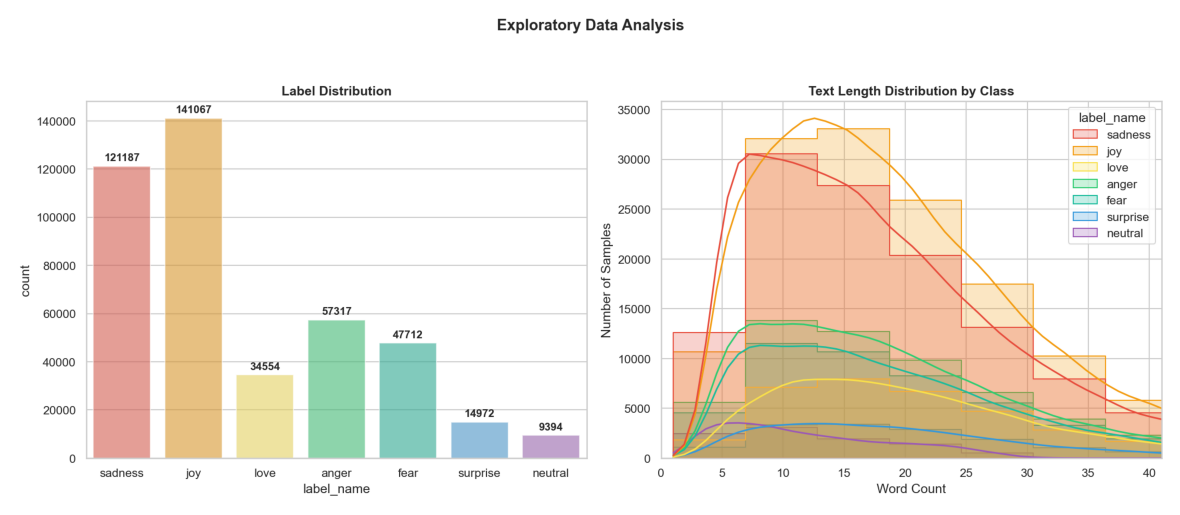

Displayed existing plot: outputs/eda/eda_overview.png


In [122]:
# -- 2.4 EDA Overview ---------------------------------------------------------
LABEL_ORDER = ["sadness", "joy", "love", "anger", "fear", "surprise", "neutral"]
df_raw['text_len'] = df_raw['text'].fillna('').apply(lambda x: len(str(x).split()))
plot_path = CFG["output_paths"]["eda"] / "eda_overview.png"

if display_saved_plot(plot_path):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sns.countplot(data=df_raw, x="label_name", order=LABEL_ORDER, palette=CUSTOM_PALETTE, ax=axes[0])
    for patch in axes[0].patches:
        patch.set_alpha(0.6)
    axes[0].set_title("Label Distribution", fontsize=12, fontweight="bold")
    for container in axes[0].containers:
        axes[0].bar_label(container, fontsize=10, fontweight="bold", padding=3)

    sns.histplot(data=df_raw, x="text_len", hue="label_name", hue_order=LABEL_ORDER,
                 bins=30, kde=True, palette=CUSTOM_PALETTE, element="step",
                 stat="count", common_norm=False, ax=axes[1])
    axes[1].set_xlim(0, df_raw['text_len'].quantile(0.95))
    axes[1].set_title("Text Length Distribution by Class", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Word Count")
    axes[1].set_ylabel("Number of Samples")

    plt.suptitle("Exploratory Data Analysis", fontsize=14, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

Neutral texts tend to be shorter. 

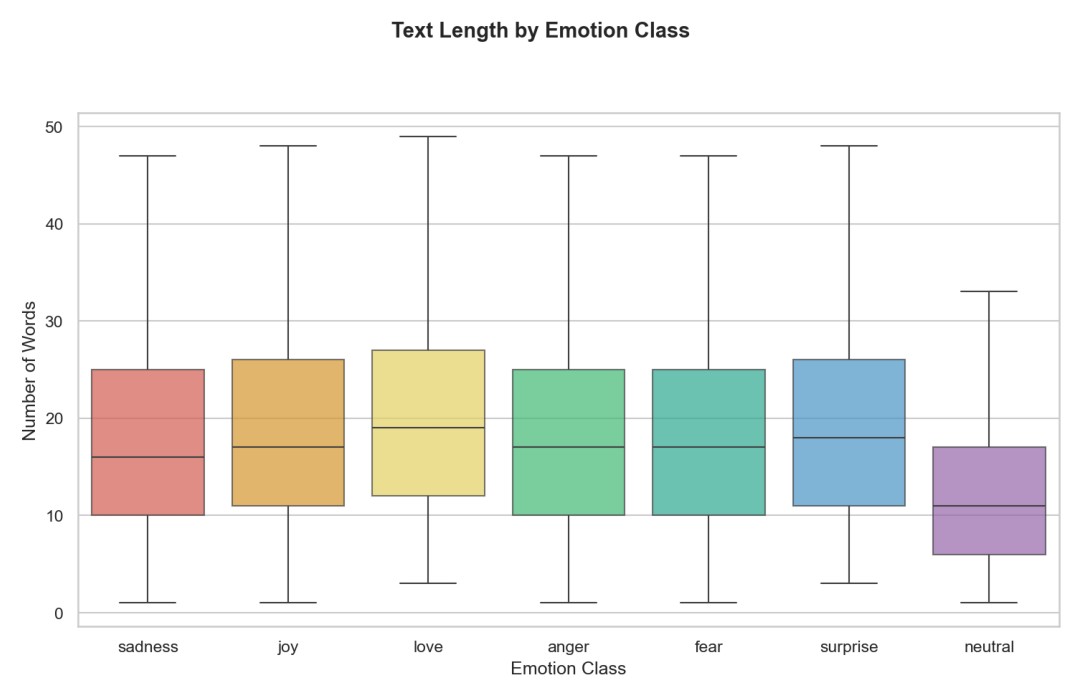

Displayed existing plot: outputs/eda/eda_text_length_by_class.png


In [123]:
# -- 2.5 Text Length by Class -------------------------------------------------
plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png"

if display_saved_plot(plot_path):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(data=df_raw, x="label_name", y="text_len", order=LABEL_ORDER,
                palette=CUSTOM_PALETTE, ax=ax, showfliers=False)
    for patch in ax.patches:
        patch.set_alpha(0.7)

    plt.suptitle("Text Length by Emotion Class", fontsize=14, fontweight="bold", y=1.05)
    ax.set_xlabel("Emotion Class")
    ax.set_ylabel("Number of Words")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

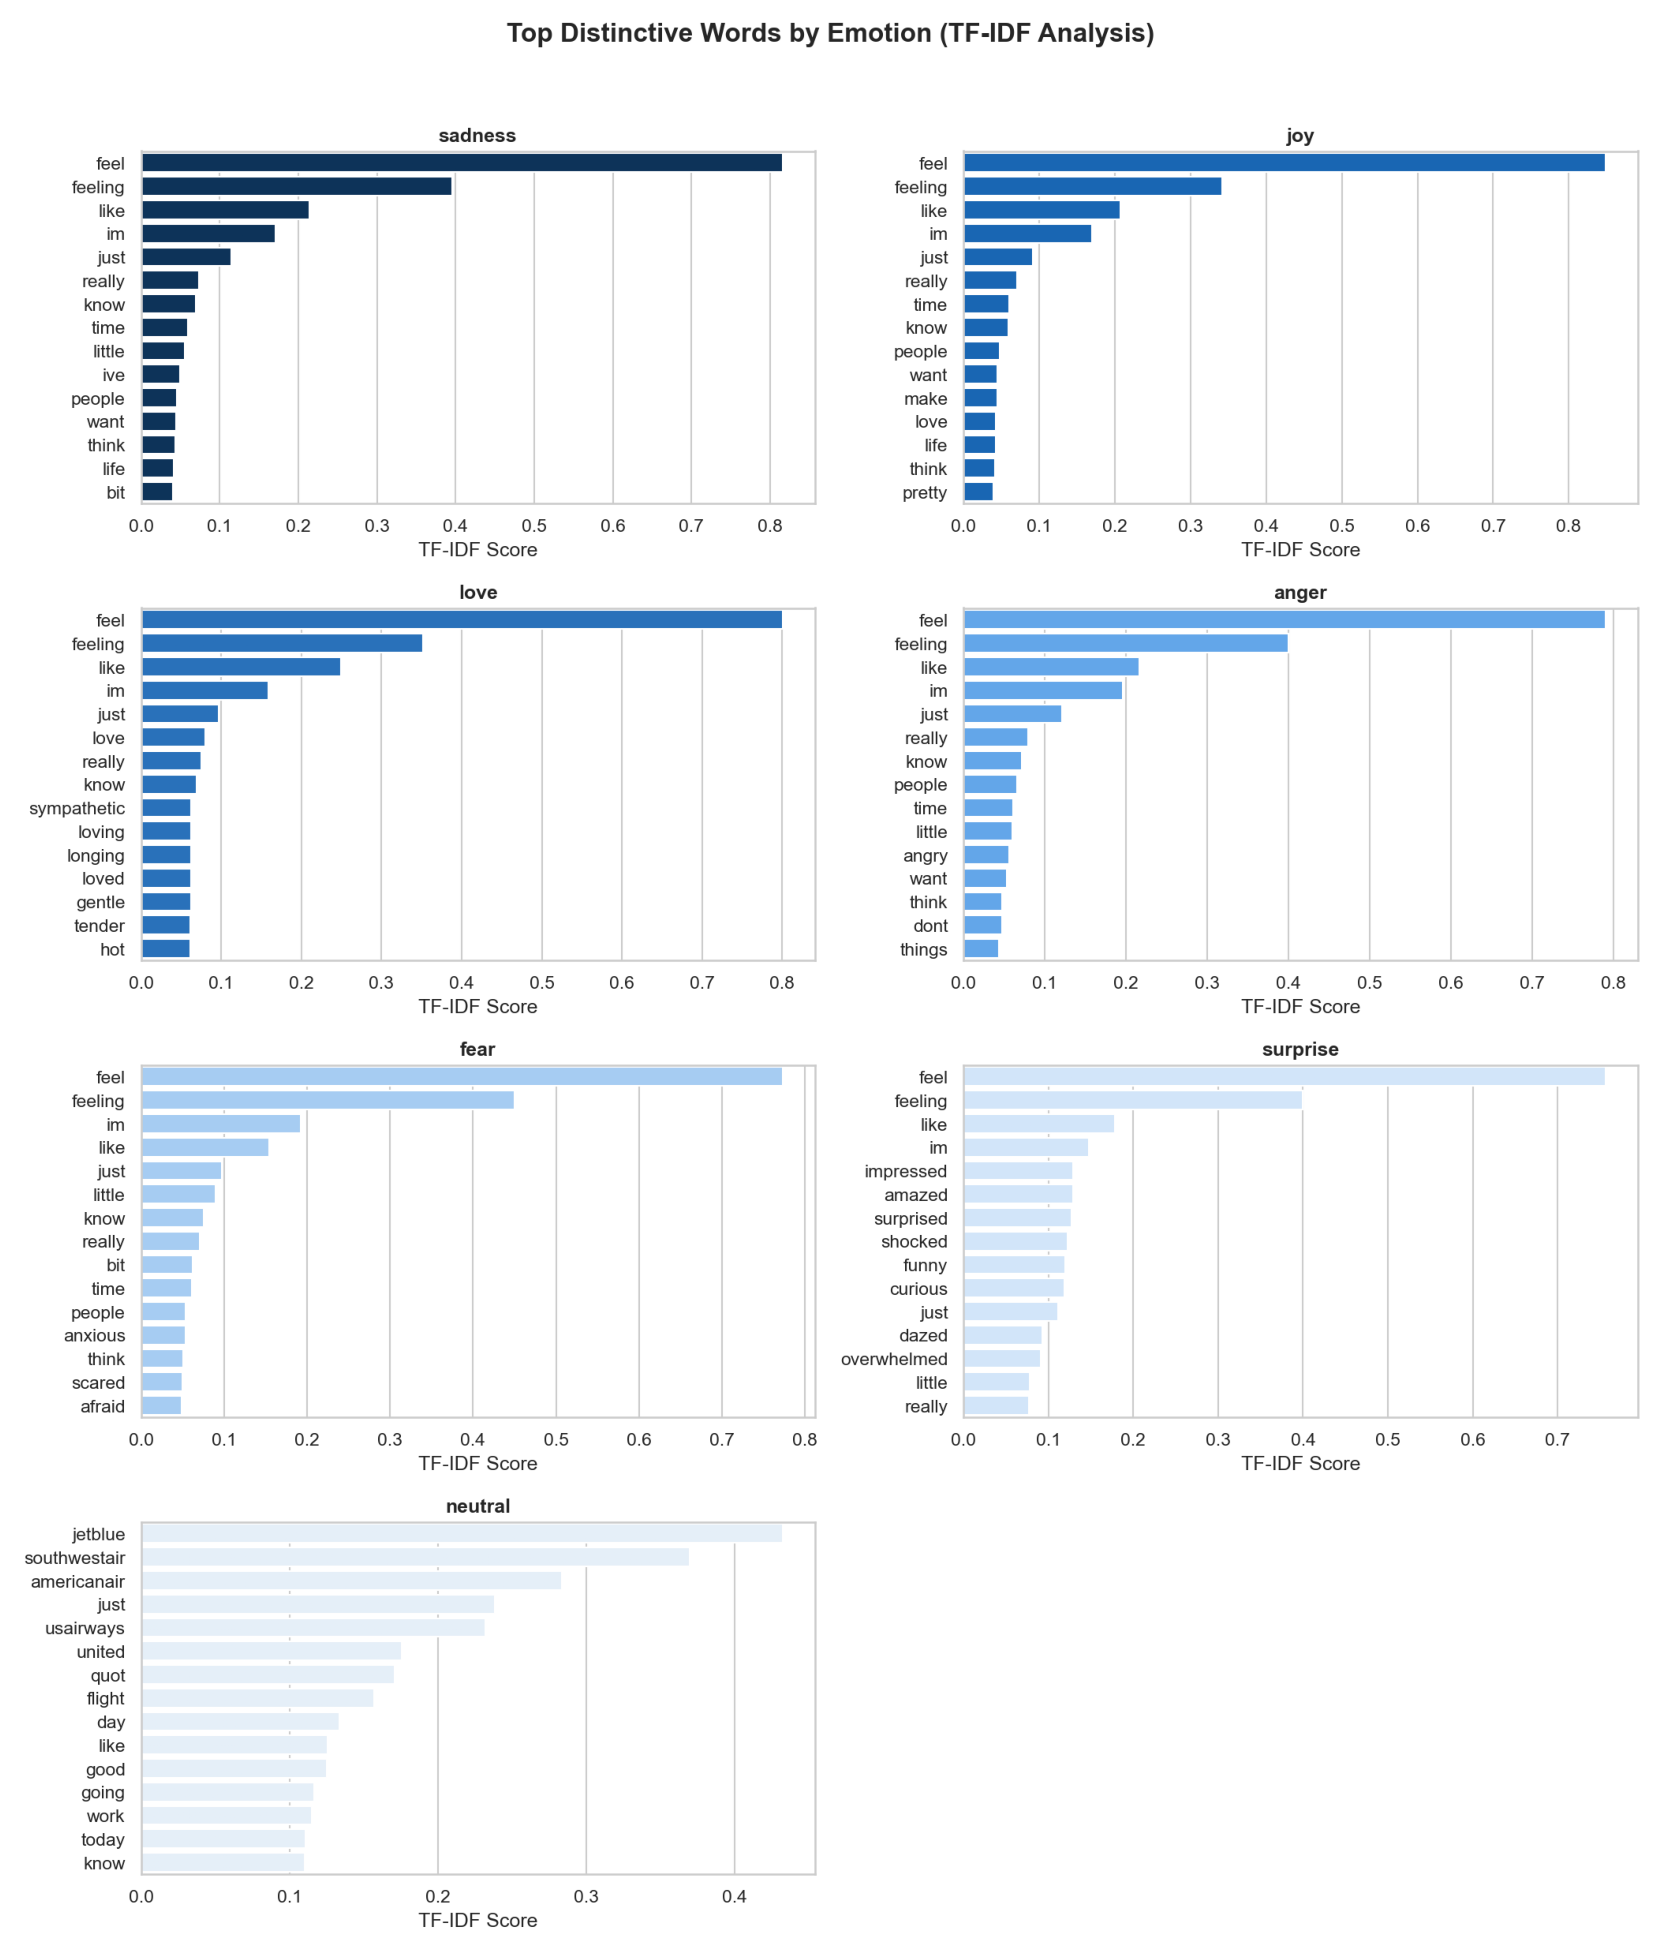

Displayed existing plot: outputs/eda/eda_top_words_tfidf.png


In [124]:
# -- 2.8 Top Words by Emotion (TF-IDF) ---------------------------------------
plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png"

if display_saved_plot(plot_path, figsize=(14, 20)):
    print(f"Displayed existing plot: {plot_path}")
else:
    cols = 2
    rows = (len(LABEL_ORDER) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
    axes = axes.flatten()

    for i, (cls, name) in enumerate(zip(CLASSES, LABEL_ORDER)):
        ax = axes[i]
        top = get_top_words_tfidf(df_raw, cls)

        if top is not None and not top.empty:
            sns.barplot(data=top, y="word", x="score", ax=ax, color=COLORS[i])
            ax.set_title(name, fontsize=12, fontweight="bold")
        else:
            ax.text(0.5, 0.5, 'No data', ha='center')

        ax.set_xlabel("TF-IDF Score")
        ax.set_ylabel("")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Top Distinctive Words by Emotion (TF-IDF Analysis)",
                 fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

<a id="section-2-results"></a>
## 2.3 Results

- The dataset is significantly imbalanced: joy (141k) and sadness (121k) dominate, while surprise (15k) and neutral (9k) are underrepresented. This imbalance will be addressed through class-balanced sampling before training.
- Text length is largely consistent across emotion classes, with a median of 15–20 words. Neutral tweets tend to be shorter (median ~12 words), which likely reflects the nature of the source dataset.
- TF-IDF analysis reveals that feel and feeling dominate across all emotion classes, offering little discriminative power. However, class-specific keywords emerge clearly — e.g. loved/loving/longing for love, angry/dont/frustrated for anger, afraid/scared/anxious for fear, overwhelmed/amazed/shocked for surprise, and dataset specific words (e.g. airline names) for neutral.

---
<a id="section-3-data-preparation"></a>
# SECTION 3 — Data Preparation


<a id="section-3-preprocessing-steps"></a>
## 3.1 Preprocessing Steps


In [125]:
# ── 3.1 datasets = [ ─────────────────────────────────────────
datasets = [
    ("raw_dataset", df_raw),
]


In [126]:
# ── 3.2 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    tqdm.pandas(desc="Preprocessing")

    for name, df in datasets:
        print(f"\nProcessing {name} ({len(df)} rows)")
        df["text_raw"] = df[CFG["text_col"]].progress_apply(normalize_text)
        df["text_clean"] = df["text_raw"].progress_apply(preprocess_from_normalized)
else:
    print("Skipping preprocessing (CFG['run_data_prep']=False)")



Processing raw_dataset (426203 rows)


Preprocessing:   0%|          | 0/426203 [00:00<?, ?it/s]

Preprocessing:   0%|          | 0/426203 [00:00<?, ?it/s]

In [127]:
# ── 3.3 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        print(f"\nCleaning {name} (before: {len(df)})")
        
        df.dropna(subset=[CFG["text_col"], CFG["label_col"]], inplace=True)
        df.drop_duplicates(subset=[CFG["text_col"]], inplace=True)
        
        print(f"Final dataset size: {len(df)}")
else:
    print("Skipping dataset cleaning (CFG['run_data_prep']=False)")



Cleaning raw_dataset (before: 426203)
Final dataset size: 403216


In [128]:
# ── 3.4 class2id = {c: i for i, c in enumerate(CLASSES)} ─────────────────────────────────────────
class2id = {c: i for i, c in enumerate(CLASSES)}
id2class = {i: c for c, i in class2id.items()}


In [129]:
# ── 3.5 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        df["label_enc"] = df[CFG["label_col"]].map(class2id)
else:
    print("Skipping label encoding for datasets (CFG['run_data_prep']=False)")


<a id="section-3-train-val-test-split"></a>
## 3.2 Train/Val/Test split


In [130]:
print(df[CFG["label_col"]].value_counts())

label
1    135104
0    118505
3     54704
4     43656
2     29394
5     12459
6      9394
Name: count, dtype: int64


We sample 12,400 examples per class for all emotion classes. The neutral class is kept at its full size (9,394) without upsampling — since sentiment models tend to overuse the neutral label as a "fallback" when uncertain, we intentionally keep it underrepresented to discourage this behavior.

In [131]:
n_samples = 12400 

dfs = []
for label, group in df_raw.groupby(CFG["label_col"]):
    if len(group) < n_samples:  # neutral class
        dfs.append(group)
    else:
        dfs.append(group.sample(n=n_samples, replace=False, random_state=CFG["seed"]))

df_balanced = pd.concat(dfs).reset_index(drop=True)

df_balanced['text_raw'] = df_balanced['text']
df_balanced['label_enc'] = df_balanced[CFG["label_col"]].astype('category').cat.codes

print("Balanced Dataset Labels:")
print(df_balanced[CFG["label_col"]].value_counts())

Balanced Dataset Labels:
label
0    12400
1    12400
2    12400
3    12400
4    12400
5    12400
6     9394
Name: count, dtype: int64


In [132]:
df_balanced.groupby("label_name").first()[["text"]].reset_index()

,label_name,text
0,anger,i feel like many people make the mistake of always waiting for the other person to go to them and get mad at the fact that they dont that it wears down on the relationship
1,fear,i feel skeptical about posting a link to my page so i wont do that but i just wanted to let you know
2,joy,i feel his innocent and loving breath on my neck
3,love,i don t feel very romantic at the moment
4,neutral,@united can you send me another confirmation email?
5,sadness,i had found that communal feeling i had been aching for and now that i had finally become more stable in my non wow life i was putting myself through it all over again
6,surprise,i feel a strange level of disappointment when other people let their moods govern their interactions


In [133]:
# -- 3.6 Train/Val/Test Splits ------------------------------------------------
if CFG["run_data_prep"]:
    required_cols = ["text_raw", "text_clean", "label_enc"]
    
    missing = [c for c in required_cols if c not in df_balanced.columns]
    if missing:
        raise ValueError(f"Dataset: missing columns {missing}")

    dataset_name = "sentiment_bcombined"
    splits = {
        dataset_name: make_splits_and_arrays(df_balanced, CFG)
    }

    s = splits[dataset_name]
    print(f"\n{dataset_name.upper()} Splits Ready:")
    print(f"  - Train: {len(s['df_train'])} samples")
    print(f"  - Val:   {len(s['df_val'])} samples")
    print(f"  - Test:  {len(s['df_test'])} samples")

    cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])
else:
    print("Skipping split creation (CFG['run_data_prep']=False)")


SENTIMENT_BCOMBINED Splits Ready:
  - Train: 58655 samples
  - Val:   12569 samples
  - Test:  12570 samples


In [134]:
# ── 3.7 if CFG["run_data_prep"]: ─────────────────────────────────────────
import pickle

save_path = CFG["data_dir"] / "processed" / "sentiment"
save_path.mkdir(parents=True, exist_ok=True)

if CFG["run_data_prep"]:
    with open(save_path / "splits.pkl", "wb") as f:
        pickle.dump(splits, f)
    print(f"Saved splits to: {save_path / 'splits.pkl'}")
else:
    print("Skipping split serialization (CFG['run_data_prep']=False)")


Saved splits to: data/processed/sentiment/splits.pkl


In [135]:
# ── 3.8 splits = locals().get("splits") or {} ─────────────────────────────────────────
splits = locals().get("splits") or {}

if not splits:
    splits = load_pickle_with_fallback(
        CFG["data_dir"] / "processed" / "sentiment" / "splits.pkl",
    )

---
<a id="section-4-baseline-models"></a>
# SECTION 4 — Baseline Models

We start with simple baselines to anchor the task. We get learning curves and test metrics, and we can see the first gains before moving to heavier models.

Pipeline: **Majority Class → TF-IDF + LogReg → TF-IDF + SVC → TF-IDF + XGBoost**  


## 4.1 Preparation & Architecture


In [136]:
# ── 4.1.1 baseline_models = build_baseline_pipeline_models(CFG) ─────────────────────────────────────────
baseline_models = build_baseline_pipeline_models(CFG)
best_models_cache = CFG["output_paths"]["metrics"] / "best_baseline_models.pkl"
tuning_cache      = CFG["output_paths"]["metrics"] / "baseline_tuning_df.pkl"
legacy_baseline_dir = CFG["model_dir"] / "baselines"

canonical_baseline_exists = any(CFG["model_dir"].glob("tf_idf_*_sentiment_*_*/best_model/model.pkl"))
legacy_baseline_exists = legacy_baseline_dir.exists() and any(legacy_baseline_dir.glob("*.pkl"))

if best_models_cache.exists() and tuning_cache.exists():
    best_baseline_models = joblib.load(best_models_cache)
    baseline_tuning_df   = joblib.load(tuning_cache)
    print("Loaded cached baseline tuning artefacts -> skipping retuning.")

elif canonical_baseline_exists or legacy_baseline_exists:
    best_baseline_models = baseline_models
    baseline_tuning_df = pd.DataFrame([
        {
            "model": name,
            "params": "reuse_existing_models",
            "val_f1_macro": np.nan,
            "selected": True,
            "note": "tuning skipped because trained baseline artefacts already exist",
        }
        for name in baseline_models.keys()
    ])
    print("Detected existing baseline artefacts -> skipping retuning.")

else:
    s = splits["sentiment_combined"]
    
    SKIP_MODELS = {} 
    
    partial_cache = CFG["output_paths"]["metrics"] / "best_baseline_models_partial.pkl"
    best_baseline_models = joblib.load(partial_cache) if partial_cache.exists() else {}
    results_baseline = []

    for name, pipeline in baseline_models.items():
        if name in SKIP_MODELS:
            print(f"Skipping {name}.")
            continue
        if name in best_baseline_models:
            print(f"Skipping {name} — already trained.")
            pipeline = best_baseline_models[name]
        else:
            print(f"\nTraining: {name}")
            import gc; gc.collect()
            pipeline.fit(s["X_train"], s["y_train"])
            best_baseline_models[name] = pipeline
            joblib.dump(best_baseline_models, partial_cache)
            print(f"  Saved checkpoint.")

        val_preds  = pipeline.predict(s["X_val"])
        test_preds = pipeline.predict(s["X_test"])
        val_f1  = f1_score(s["y_val"],  val_preds,  average="macro", zero_division=0)
        test_f1 = f1_score(s["y_test"], test_preds, average="macro", zero_division=0)
        results_baseline.append({
            "model": name, "val_f1_macro": val_f1,
            "test_f1_macro": test_f1, "selected": True
        })

    baseline_tuning_df = pd.DataFrame(results_baseline).sort_values("val_f1_macro", ascending=False)
    joblib.dump(best_baseline_models, best_models_cache)
    joblib.dump(baseline_tuning_df,   tuning_cache)
    print("Baseline training completed.")

display(baseline_tuning_df)


Loaded cached baseline tuning artefacts -> skipping retuning.


,model,val_f1_macro,test_f1_macro,selected
0,TF-IDF + SVC,0.952600,0.951226,True
1,TF-IDF + LogReg,0.948342,0.946125,True
3,TF-IDF + XGBoost,0.920236,0.923218,True
2,Majority Class,0.035714,0.035714,True


In [137]:
# ── 4.1.2 le = DictLabelEncoder(class2id) ─────────────────────────────────────────
le = DictLabelEncoder(class2id)

## 4.2 Training


In [138]:
# ── 4.2.1 Learning curves across dataset sizes ──────────────────────────────────
from sklearn.utils import resample
import numpy as np

s = splits["sentiment_bcombined"]
size_keys = ["1k", "5k", "10k", "30k", "60k"]
sizes = [1000, 5000, 10000, 30000, len(s["X_train"])]

for key, n in zip(size_keys, sizes):
    idx = resample(
        np.arange(len(s["X_train"])),
        n_samples=min(n, len(s["X_train"])),
        replace=False,
        random_state=42,
    )
    idx = np.asarray(idx)

    splits[f"sentiment_{key}"] = {
        "df_train": s["df_train"].iloc[idx].reset_index(drop=True),
        "df_val": s["df_val"].copy(),
        "df_test": s["df_test"].copy(),

        "X_train": np.asarray(s["X_train"], dtype=object)[idx],
        "X_val": np.asarray(s["X_val"], dtype=object),
        "X_test": np.asarray(s["X_test"], dtype=object),

        "X_train_raw": np.asarray(s["X_train_raw"], dtype=object)[idx],
        "X_val_raw": np.asarray(s["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(s["X_test_raw"], dtype=object),

        "y_train": np.asarray(s["y_train"], dtype=np.int64)[idx],
        "y_val": np.asarray(s["y_val"], dtype=np.int64),
        "y_test": np.asarray(s["y_test"], dtype=np.int64),
    }

sentiment_split_keys = ["sentiment_1k", "sentiment_5k", "sentiment_10k", "sentiment_30k", "sentiment_60k"]

baseline_curve_df, baseline_eval_df, BASELINE_MODEL_REGISTRY = train_baselines_across_splits(
    models=best_baseline_models,
    splits=splits,
    split_keys=sentiment_split_keys,
    label_encoder=le,
    model_root=CFG["model_dir"],
    primary_curve_split="val",
    single_point_models=("Majority Class",),
    single_point_key="sentiment_60k",
)

display(baseline_eval_df)

Baseline train/eval:   0%|          | 0/16 [00:00<?, ?it/s]


  TF-IDF + LogReg [sentiment_1k] | VAL
  Accuracy      : 0.6619
  F1 (macro)    : 0.6629
  F1 (weighted) : 0.6577

              precision    recall  f1-score   support

           0       0.51      0.48      0.49      1860
           1       0.52      0.48      0.50      1860
           2       0.71      0.76      0.74      1860
           3       0.66      0.60      0.63      1860
           4       0.62      0.62      0.62      1860
           5       0.84      0.88      0.86      1860
           6       0.76      0.86      0.81      1409

    accuracy                           0.66     12569
   macro avg       0.66      0.67      0.66     12569
weighted avg       0.66      0.66      0.66     12569


  TF-IDF + LogReg [sentiment_1k] | TEST
  Accuracy      : 0.6685
  F1 (macro)    : 0.6692
  F1 (weighted) : 0.6640

              precision    recall  f1-score   support

           0       0.51      0.48      0.50      1860
           1       0.51      0.47      0.49      1860
       

,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,model_tag,model_path,status
0,Majority Class,sentiment_60k,58655,test,0.147971,0.036828,0.038146,NaN,Majority Class [sentiment_60k],models/majority_class_sentiment_60k_20260313_122653/best_model/model.pkl,loaded
1,Majority Class,sentiment_60k,58655,val,0.147983,0.036831,0.038152,NaN,Majority Class [sentiment_60k],models/majority_class_sentiment_60k_20260313_122653/best_model/model.pkl,loaded
2,TF-IDF + LogReg,sentiment_1k,1000,test,0.668496,0.669237,0.664020,NaN,TF-IDF + LogReg [sentiment_1k],models/tf_idf_logreg_sentiment_1k_20260313_122648/best_model/model.pkl,loaded
3,TF-IDF + LogReg,sentiment_5k,5000,test,0.893636,0.893765,0.892822,NaN,TF-IDF + LogReg [sentiment_5k],models/tf_idf_logreg_sentiment_5k_20260313_122649/best_model/model.pkl,loaded
4,TF-IDF + LogReg,sentiment_10k,10000,test,0.922275,0.922390,0.921819,NaN,TF-IDF + LogReg [sentiment_10k],models/tf_idf_logreg_sentiment_10k_20260313_122650/best_model/model.pkl,loaded
5,TF-IDF + LogReg,sentiment_30k,30000,test,0.940175,0.940161,0.939941,NaN,TF-IDF + LogReg [sentiment_30k],models/tf_idf_logreg_sentiment_30k_20260313_122651/best_model/model.pkl,loaded
6,TF-IDF + LogReg,sentiment_60k,58655,test,0.944869,0.944978,0.944664,NaN,TF-IDF + LogReg [sentiment_60k],models/tf_idf_logreg_sentiment_60k_20260313_122653/best_model/model.pkl,loaded
7,TF-IDF + LogReg,sentiment_1k,1000,val,0.661866,0.662899,0.657727,NaN,TF-IDF + LogReg [sentiment_1k],models/tf_idf_logreg_sentiment_1k_20260313_122648/best_model/model.pkl,loaded
8,TF-IDF + LogReg,sentiment_5k,5000,val,0.892116,0.892370,0.891532,NaN,TF-IDF + LogReg [sentiment_5k],models/tf_idf_logreg_sentiment_5k_20260313_122649/best_model/model.pkl,loaded
9,TF-IDF + LogReg,sentiment_10k,10000,val,0.920439,0.920436,0.920018,NaN,TF-IDF + LogReg [sentiment_10k],models/tf_idf_logreg_sentiment_10k_20260313_122650/best_model/model.pkl,loaded


In [139]:
# ── 4.2.2 Learning curves across dataset sizes ──────────────────────────────────
from sklearn.utils import resample

s = splits["sentiment_bcombined"]
size_keys = ["1k", "5k", "10k", "30k", "60k"]
sizes     = [1000, 5000, 10000, 30000, len(s["X_train"])]

for key, n in zip(size_keys, sizes):
    idx = resample(range(len(s["X_train"])), n_samples=min(n, len(s["X_train"])), random_state=42)
    splits[f"sentiment_{key}"] = {
        **s,
        "X_train": [s["X_train"][i] for i in idx],
        "y_train": s["y_train"][idx],
    }

sentiment_split_keys = ["sentiment_1k", "sentiment_5k", "sentiment_10k", "sentiment_30k", "sentiment_60k"]

baseline_curve_df, baseline_eval_df, BASELINE_MODEL_REGISTRY = train_baselines_across_splits(
    models=best_baseline_models,
    splits=splits,
    split_keys=sentiment_split_keys,
    label_encoder=le,
    model_root=CFG["model_dir"],
    primary_curve_split="val",
    single_point_models=("Majority Class",),
    single_point_key="sentiment_60k",
)

display(baseline_eval_df)

Baseline train/eval:   0%|          | 0/16 [00:00<?, ?it/s]


  TF-IDF + LogReg [sentiment_1k] | VAL
  Accuracy      : 0.6619
  F1 (macro)    : 0.6629
  F1 (weighted) : 0.6577

              precision    recall  f1-score   support

           0       0.51      0.48      0.49      1860
           1       0.52      0.48      0.50      1860
           2       0.71      0.76      0.74      1860
           3       0.66      0.60      0.63      1860
           4       0.62      0.62      0.62      1860
           5       0.84      0.88      0.86      1860
           6       0.76      0.86      0.81      1409

    accuracy                           0.66     12569
   macro avg       0.66      0.67      0.66     12569
weighted avg       0.66      0.66      0.66     12569


  TF-IDF + LogReg [sentiment_1k] | TEST
  Accuracy      : 0.6685
  F1 (macro)    : 0.6692
  F1 (weighted) : 0.6640

              precision    recall  f1-score   support

           0       0.51      0.48      0.50      1860
           1       0.51      0.47      0.49      1860
       

,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,model_tag,model_path,status
0,Majority Class,sentiment_60k,58655,test,0.147971,0.036828,0.038146,NaN,Majority Class [sentiment_60k],models/majority_class_sentiment_60k_20260313_122653/best_model/model.pkl,loaded
1,Majority Class,sentiment_60k,58655,val,0.147983,0.036831,0.038152,NaN,Majority Class [sentiment_60k],models/majority_class_sentiment_60k_20260313_122653/best_model/model.pkl,loaded
2,TF-IDF + LogReg,sentiment_1k,1000,test,0.668496,0.669237,0.664020,NaN,TF-IDF + LogReg [sentiment_1k],models/tf_idf_logreg_sentiment_1k_20260313_122648/best_model/model.pkl,loaded
3,TF-IDF + LogReg,sentiment_5k,5000,test,0.893636,0.893765,0.892822,NaN,TF-IDF + LogReg [sentiment_5k],models/tf_idf_logreg_sentiment_5k_20260313_122649/best_model/model.pkl,loaded
4,TF-IDF + LogReg,sentiment_10k,10000,test,0.922275,0.922390,0.921819,NaN,TF-IDF + LogReg [sentiment_10k],models/tf_idf_logreg_sentiment_10k_20260313_122650/best_model/model.pkl,loaded
5,TF-IDF + LogReg,sentiment_30k,30000,test,0.940175,0.940161,0.939941,NaN,TF-IDF + LogReg [sentiment_30k],models/tf_idf_logreg_sentiment_30k_20260313_122651/best_model/model.pkl,loaded
6,TF-IDF + LogReg,sentiment_60k,58655,test,0.944869,0.944978,0.944664,NaN,TF-IDF + LogReg [sentiment_60k],models/tf_idf_logreg_sentiment_60k_20260313_122653/best_model/model.pkl,loaded
7,TF-IDF + LogReg,sentiment_1k,1000,val,0.661866,0.662899,0.657727,NaN,TF-IDF + LogReg [sentiment_1k],models/tf_idf_logreg_sentiment_1k_20260313_122648/best_model/model.pkl,loaded
8,TF-IDF + LogReg,sentiment_5k,5000,val,0.892116,0.892370,0.891532,NaN,TF-IDF + LogReg [sentiment_5k],models/tf_idf_logreg_sentiment_5k_20260313_122649/best_model/model.pkl,loaded
9,TF-IDF + LogReg,sentiment_10k,10000,val,0.920439,0.920436,0.920018,NaN,TF-IDF + LogReg [sentiment_10k],models/tf_idf_logreg_sentiment_10k_20260313_122650/best_model/model.pkl,loaded


## 4.3 Results


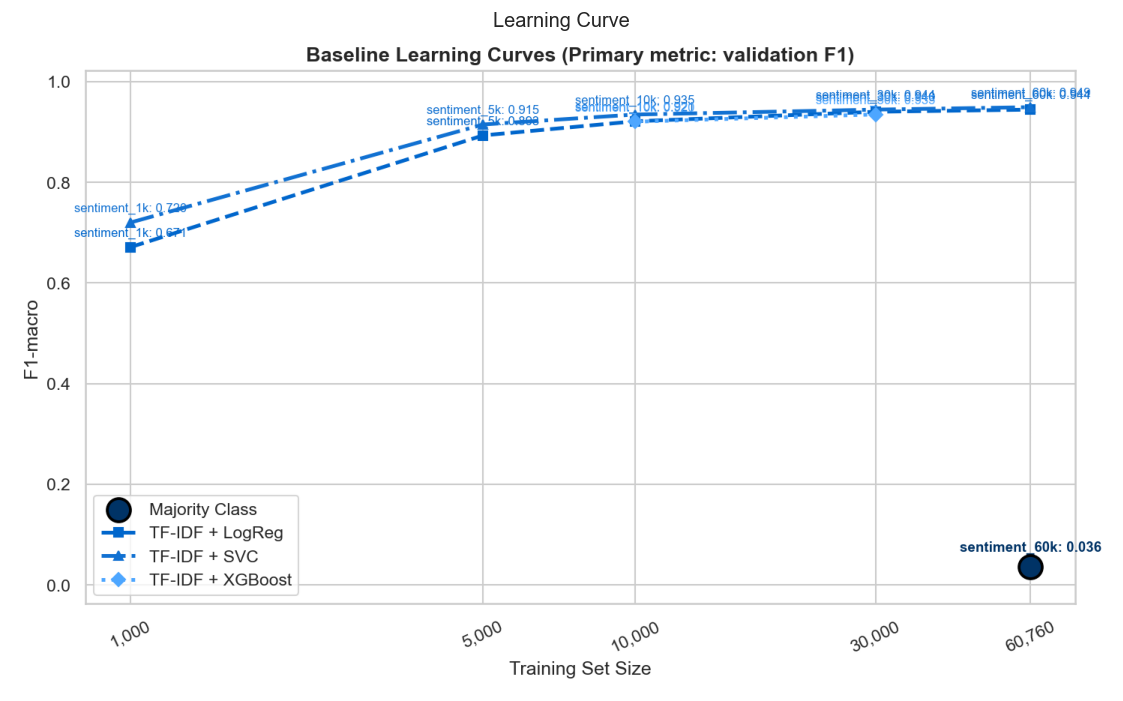

Displayed existing learning curve: outputs/plots/learning_curves/baseline_learning_curves.png


,model,split_key,train_size,f1_macro
0,Majority Class,sentiment_60k,58655,0.036831
1,TF-IDF + LogReg,sentiment_1k,1000,0.662899
2,TF-IDF + LogReg,sentiment_5k,5000,0.892370
3,TF-IDF + LogReg,sentiment_10k,10000,0.920436
4,TF-IDF + LogReg,sentiment_30k,30000,0.939132
5,TF-IDF + LogReg,sentiment_60k,58655,0.942919
6,TF-IDF + SVC,sentiment_1k,1000,0.700168
7,TF-IDF + SVC,sentiment_5k,5000,0.914732
8,TF-IDF + SVC,sentiment_10k,10000,0.931594
9,TF-IDF + SVC,sentiment_30k,30000,0.945872


In [142]:
# ── 4.3.1 plot_learning_curve_from_metrics( ─────────────────────────────────────────
plot_learning_curve_from_metrics(
    baseline_curve_df,
    save_path=CFG["output_paths"]["plots_learning"] / "baseline_learning_curves.png",
)


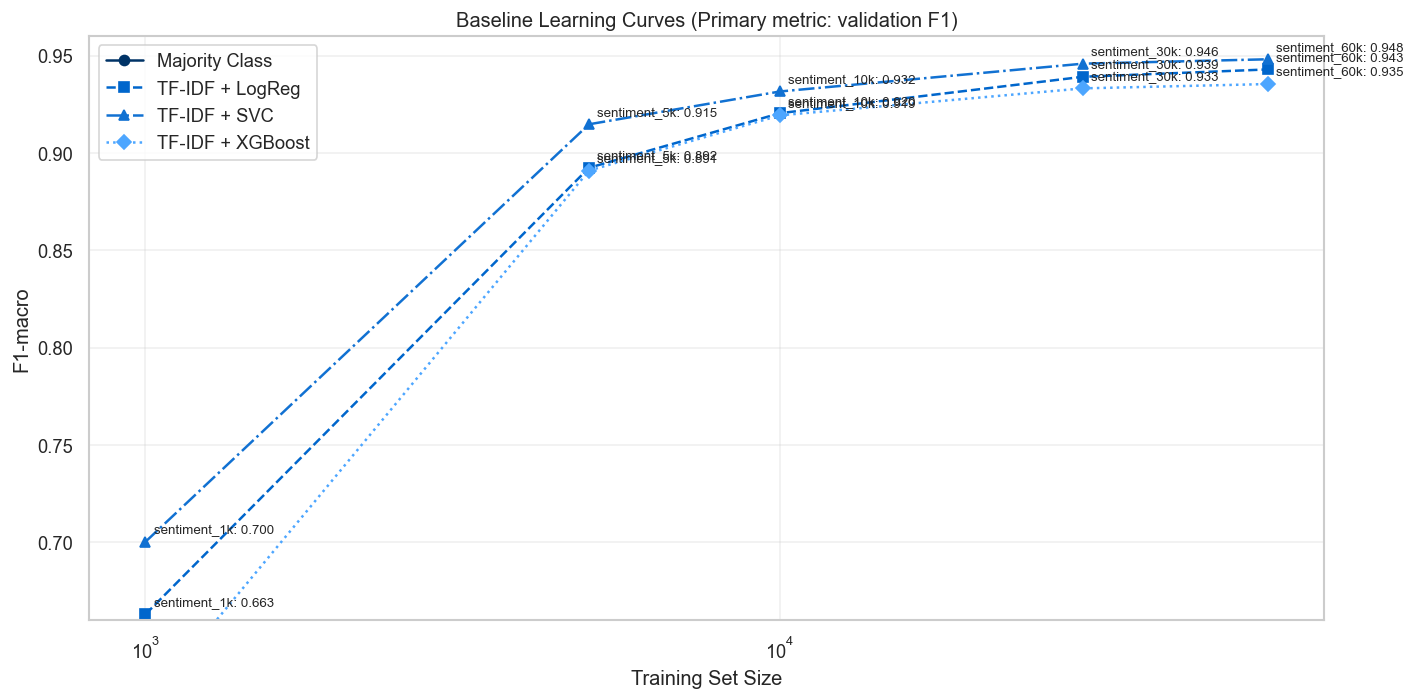

In [143]:
# ── 4.3.2 baseline_learning_curves_zoom ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

line_styles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D"]

for i, (model_name, group) in enumerate(baseline_curve_df.groupby("model")):
    group = group.sort_values("train_size")
    ls = line_styles[i % len(line_styles)]
    mk = markers[i % len(markers)]
    ax.plot(group["train_size"], group["f1_macro"],
            marker=mk, linestyle=ls, label=model_name)
    for _, row in group.iterrows():
        ax.annotate(f"{row['split_key']}: {row['f1_macro']:.3f}",
                    (row["train_size"], row["f1_macro"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Training Set Size")
ax.set_ylabel("F1-macro")
ax.set_title("Baseline Learning Curves (Primary metric: validation F1)")
ax.set_xscale("log")
ax.set_ylim(0.66, 0.96)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CFG["output_paths"]["plots_learning"] / "baseline_learning_curves_zoom.png", dpi=120)
plt.show()

In [144]:
# ── 4.3.3 Persist baseline metrics and model registry ─────────────────────────────────────────
metrics_dir = CFG["output_paths"]["metrics"]
metrics_dir.mkdir(parents=True, exist_ok=True)

baseline_curve_df.to_csv(metrics_dir / "baseline_curve_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "baseline_curve_metrics.pkl")

baseline_eval_df.to_csv(metrics_dir / "baseline_eval_metrics.csv", index=False)
joblib.dump(baseline_eval_df, metrics_dir / "baseline_eval_metrics.pkl")

baseline_curve_df.to_csv(metrics_dir / "classical_lc_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "classical_lc_metrics.pkl")

with open(metrics_dir / "baseline_model_registry.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_MODEL_REGISTRY, f, indent=2)

for row in baseline_curve_df.itertuples(index=False):
    RESULTS[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}


---
<a id="section-5-static-embeddings-fasttext"></a>
# SECTION 5 — Static Embeddings + Models (FastText, MLP + CNN)

We move to fixed embeddings with lightweight neural models. We get shared vocab and embedding artefacts plus MLP and CNN runs, and we can already check how much extra capacity helps once the data grow.

## 5.1 Preparation & Architecture

Builds a vocabulary from the training set and creates a fixed embedding matrix  
shared by all deep learning models (MLP, CNN, BiLSTM).

**Architecture:**

- *EmbeddingMLP* — mean-pool embeddings → FC head (document-level baseline).
- *TextCNN* (Kim 2014) — parallel Conv1d filters [2, 3, 4] → global max-pool → concat → FC.

In [145]:
# ── 5.1.1 Prepare split keys for deep learning experiments ─────────────────────
sentiment_split_keys_dl = ["sentiment_1k", "sentiment_5k", "sentiment_10k", "sentiment_30k", "sentiment_60k"]
base_split_key_dl = "sentiment_60k"

base_split = splits[base_split_key_dl]
X_train     = base_split["X_train"]
X_val       = base_split["X_val"]
X_test      = base_split["X_test"]
X_train_raw = base_split["X_train_raw"]
X_val_raw   = base_split["X_val_raw"]
X_test_raw  = base_split["X_test_raw"]
y_train     = base_split["y_train"]
y_val       = base_split["y_val"]
y_test      = base_split["y_test"]
df_train    = base_split["df_train"]
df_val      = base_split["df_val"]
df_test     = base_split["df_test"]

for name in sentiment_split_keys_dl:
    s = splits[name]
    print(
        f"{name}: train={len(s['X_train']):,} | "
        f"val={len(s['X_val']):,} | test={len(s['X_test']):,}"
    )
print(f"Base split for shared vocabulary/embeddings: {base_split_key_dl}")


sentiment_1k: train=1,000 | val=12,569 | test=12,570
sentiment_5k: train=5,000 | val=12,569 | test=12,570
sentiment_10k: train=10,000 | val=12,569 | test=12,570
sentiment_30k: train=30,000 | val=12,569 | test=12,570
sentiment_60k: train=58,655 | val=12,569 | test=12,570
Base split for shared vocabulary/embeddings: sentiment_60k


In [146]:
# ── 5.1.2 vocab = build_vocab( ─────────────────────────────────────────
vocab = build_vocab(
    X_train,
    max_vocab=50_000,
    min_freq=1,
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"],
)

print(f"Vocabulary size: {len(vocab):,}")


Vocabulary size: 26,143


In [147]:
# ── 5.1.3 vocab_words = set(vocab.keys()) ─────────────────────────────────────────
vocab_words = set(vocab.keys())
total = 0
oov = 0

for text in X_val:   # or X_test
    toks = str(text).split()
    total += len(toks)
    oov += sum(tok not in vocab_words for tok in toks)

print(f"OOV rate: {oov/total:.2%}  ({oov}/{total})")


OOV rate: 4.38%  (5116/116864)


In [55]:
# ── 5.1.4 embedding_matrix = load_embedding_matrix( ─────────────────────────────────────────
embedding_matrix = load_embedding_matrix(
    vocab, CFG["embedding_model"], CFG["embedding_dim"]
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")


INFO:gensim.downloader:Creating /Users/alalariceva/gensim-data


Loading fasttext-wiki-news-subwords-300 ...
[=-------------------------------------------------] 2.4% 23.4/958.4MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[=====---------------------------------------------] 10.9% 104.5/958.4MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[===============================================---] 95.9% 919.0/958.4MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



INFO:gensim.downloader:fasttext-wiki-news-subwords-300 downloaded
INFO:gensim.models.keyedvectors:loading projection weights from /Users/alalariceva/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz
INFO:gensim.utils:KeyedVectors lifecycle event {'msg': 'loaded (999999, 300) matrix of type float32 from /Users/alalariceva/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-03-13T13:41:01.239055', 'gensim': '4.4.0', 'python': '3.11.11 | packaged by conda-forge | (main, Dec  5 2024, 08:47:03) [Clang 18.1.8 ]', 'platform': 'macOS-13.5.1-arm64-arm-64bit', 'event': 'load_word2vec_format'}


Coverage: 76.1%  (hits=19889, misses=6254)
Embedding matrix shape: (26143, 300)


In [158]:
# ── 5.1.5 seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"]) ─────────────────────────────────────────
seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")


seq_train: (58655, 128) | seq_val: (12569, 128) | seq_test: (12570, 128)


In [159]:
# ── 5.1.6 Base split loaders (kept for compatibility with downstream code) ─────────────────────────────────────────
loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("Base split DataLoaders ready.")

dl_split_data = {}
for split_key in sentiment_split_keys_dl:
    s = splits[split_key]

    seq_tr = texts_to_sequences(s["X_train"], vocab, CFG["max_seq_len"])
    seq_va = texts_to_sequences(s["X_val"],   vocab, CFG["max_seq_len"])
    seq_te = texts_to_sequences(s["X_test"],  vocab, CFG["max_seq_len"])

    l_tr, l_va, l_te = make_loaders(
        seq_tr, s["y_train"],
        seq_va, s["y_val"],
        seq_te, s["y_test"],
        batch_size=CFG["dl_batch_size"]
    )

    dl_split_data[split_key] = {
        "loader_train": l_tr,
        "loader_val": l_va,
        "loader_test": l_te,
        "y_val": s["y_val"],
        "y_test": s["y_test"],
        "df_test": s["df_test"],
        "train_size": len(s["X_train"]),
    }

    print(
        f"{split_key}: seq_train={seq_tr.shape}, seq_val={seq_va.shape}, "
        f"seq_test={seq_te.shape}"
    )

print("All deep-learning split DataLoaders ready.")


Base split DataLoaders ready.
sentiment_1k: seq_train=(1000, 128), seq_val=(12569, 128), seq_test=(12570, 128)
sentiment_5k: seq_train=(5000, 128), seq_val=(12569, 128), seq_test=(12570, 128)
sentiment_10k: seq_train=(10000, 128), seq_val=(12569, 128), seq_test=(12570, 128)
sentiment_30k: seq_train=(30000, 128), seq_val=(12569, 128), seq_test=(12570, 128)
sentiment_60k: seq_train=(58655, 128), seq_val=(12569, 128), seq_test=(12570, 128)
All deep-learning split DataLoaders ready.


In [160]:
# ── 5.1.7 class EmbeddingMLP(nn.Module): ─────────────────────────────────────────
class EmbeddingMLP(nn.Module):
    """
    Mean-pools pre-trained token embeddings, then applies a two-layer MLP.
    Serves as the lightweight "GloVe + MLP" step in the pipeline.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : hidden layer width
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are not updated during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 256, dropout: float = 0.3,
                 freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)       
        emb  = self.embedding(x) * mask            
        doc  = emb.sum(1) / mask.sum(1).clamp(min=1)  
        return self.fc(doc)


# ── 5.1.8 TextCNN ───────────────────────────────────────────────────────────────
class TextCNN(nn.Module):
    """
    Parallel Conv1d filters over token embeddings with global max-pooling.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    num_filters      : number of filters per kernel size
    kernel_sizes     : list of filter heights (e.g. [2, 3, 4])
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are frozen
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 num_filters: int = 128, kernel_sizes: list = None,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]

        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)  
        pooled = [
            F.relu(conv(emb)).max(dim=2).values  
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


print("EmbeddingMLP and TextCNN architectures defined.")


EmbeddingMLP and TextCNN architectures defined.


## 5.2 Training

Runs deep-model training/evaluation and produces deep/unified learning-curve artefacts.



===== GloVe MLP | sentiment_1k =====
GloVe MLP [sentiment_1k]: best checkpoint found -> skip retraining (models/glove_mlp_sentiment_1k_20260313_134102/best_model/best.pt)


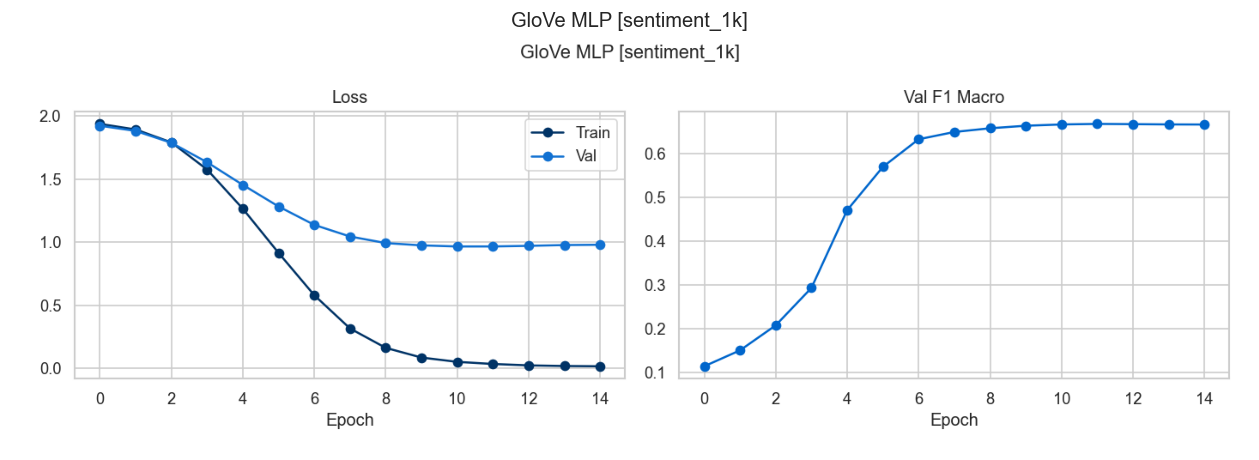

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_sentiment_1k.png

  GloVe MLP [sentiment_1k] | VAL
  Accuracy      : 0.6397
  F1 (macro)    : 0.6411
  F1 (weighted) : 0.6405

              precision    recall  f1-score   support

           0       0.58      0.50      0.54      1860
           1       0.49      0.67      0.56      1860
           2       0.67      0.65      0.66      1860
           3       0.62      0.69      0.65      1860
           4       0.70      0.64      0.67      1860
           5       0.72      0.80      0.76      1860
           6       0.93      0.51      0.66      1409

    accuracy                           0.64     12569
   macro avg       0.67      0.64      0.64     12569
weighted avg       0.66      0.64      0.64     12569

Final validation F1 (macro) [GloVe MLP [sentiment_1k]]: 0.6411

  GloVe MLP [sentiment_1k] | TEST
  Accuracy      : 0.6375
  F1 (macro)    : 0.6399
  F1 (weighted) : 0.6387

              preci

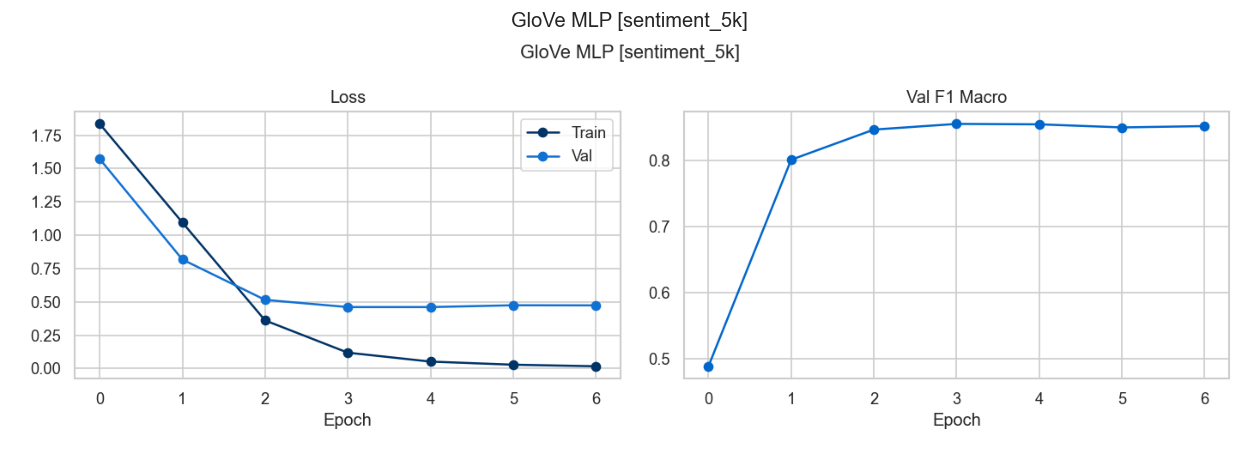

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_sentiment_5k.png

  GloVe MLP [sentiment_5k] | VAL
  Accuracy      : 0.8373
  F1 (macro)    : 0.8368
  F1 (weighted) : 0.8370

              precision    recall  f1-score   support

           0       0.79      0.80      0.80      1860
           1       0.78      0.77      0.78      1860
           2       0.87      0.88      0.88      1860
           3       0.85      0.86      0.85      1860
           4       0.84      0.84      0.84      1860
           5       0.86      0.91      0.88      1860
           6       0.90      0.77      0.83      1409

    accuracy                           0.84     12569
   macro avg       0.84      0.84      0.84     12569
weighted avg       0.84      0.84      0.84     12569

Final validation F1 (macro) [GloVe MLP [sentiment_5k]]: 0.8368

  GloVe MLP [sentiment_5k] | TEST
  Accuracy      : 0.8379
  F1 (macro)    : 0.8383
  F1 (weighted) : 0.8379

              preci

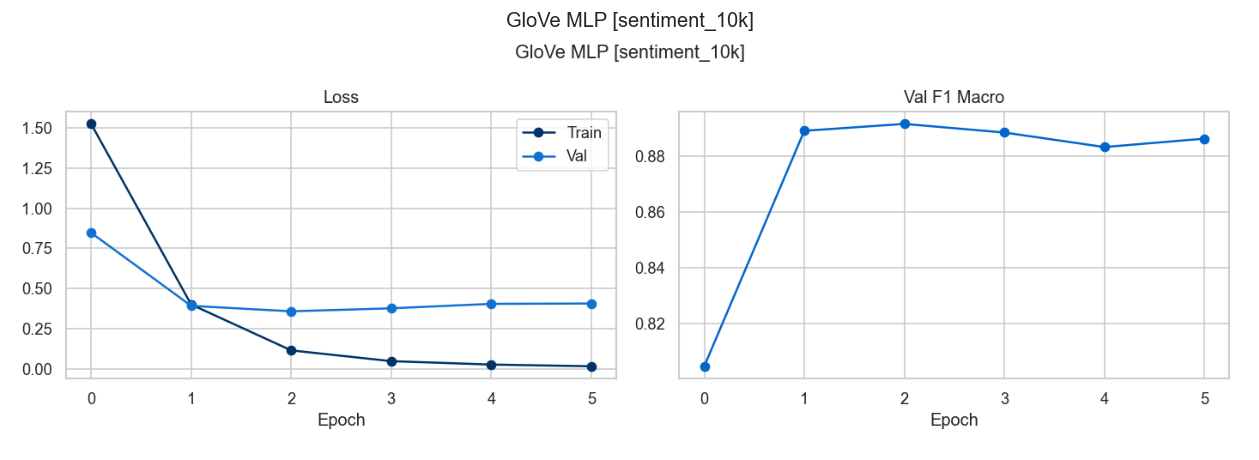

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_sentiment_10k.png

  GloVe MLP [sentiment_10k] | VAL
  Accuracy      : 0.8815
  F1 (macro)    : 0.8815
  F1 (weighted) : 0.8815

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1860
           1       0.82      0.87      0.84      1860
           2       0.92      0.89      0.90      1860
           3       0.88      0.90      0.89      1860
           4       0.87      0.88      0.87      1860
           5       0.90      0.93      0.91      1860
           6       0.92      0.85      0.88      1409

    accuracy                           0.88     12569
   macro avg       0.88      0.88      0.88     12569
weighted avg       0.88      0.88      0.88     12569

Final validation F1 (macro) [GloVe MLP [sentiment_10k]]: 0.8815

  GloVe MLP [sentiment_10k] | TEST
  Accuracy      : 0.8800
  F1 (macro)    : 0.8806
  F1 (weighted) : 0.8801

              p

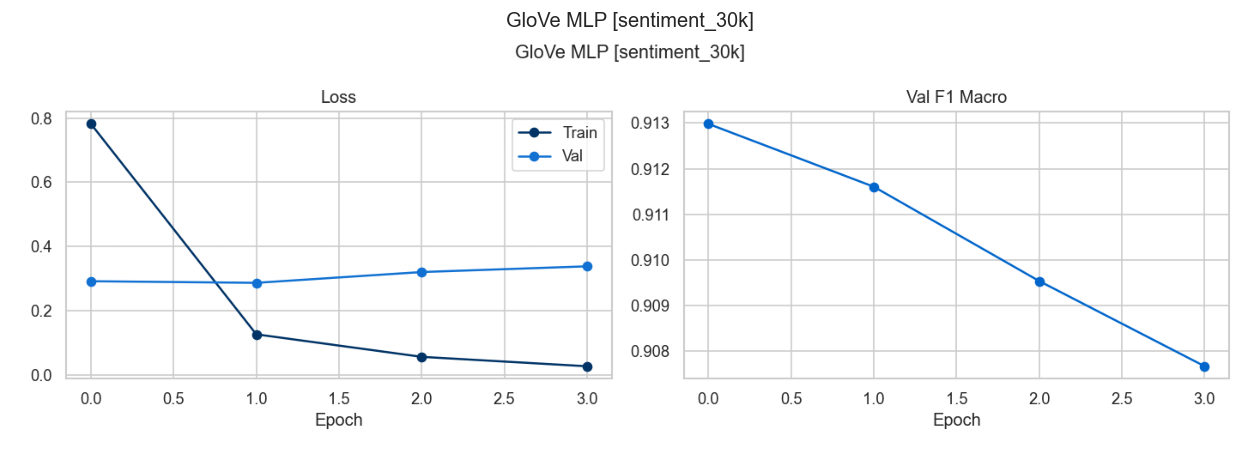

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_sentiment_30k.png

  GloVe MLP [sentiment_30k] | VAL
  Accuracy      : 0.9100
  F1 (macro)    : 0.9103
  F1 (weighted) : 0.9098

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1860
           1       0.90      0.88      0.89      1860
           2       0.91      0.94      0.93      1860
           3       0.90      0.93      0.91      1860
           4       0.92      0.87      0.89      1860
           5       0.91      0.96      0.93      1860
           6       0.94      0.91      0.92      1409

    accuracy                           0.91     12569
   macro avg       0.91      0.91      0.91     12569
weighted avg       0.91      0.91      0.91     12569

Final validation F1 (macro) [GloVe MLP [sentiment_30k]]: 0.9103

  GloVe MLP [sentiment_30k] | TEST
  Accuracy      : 0.9115
  F1 (macro)    : 0.9116
  F1 (weighted) : 0.9112

              p

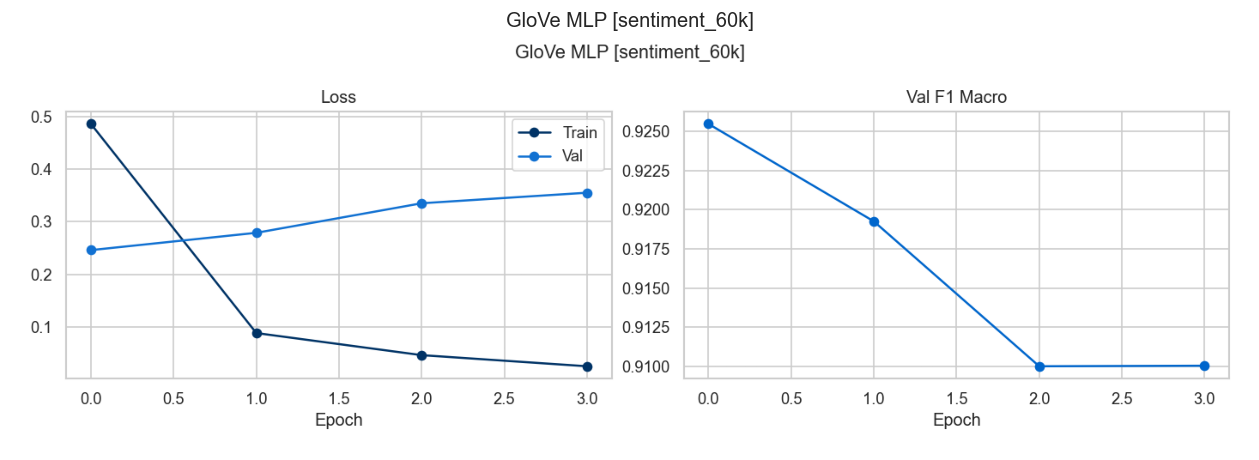

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_sentiment_60k.png

  GloVe MLP [sentiment_60k] | VAL
  Accuracy      : 0.9161
  F1 (macro)    : 0.9168
  F1 (weighted) : 0.9161

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1860
           1       0.89      0.90      0.90      1860
           2       0.93      0.92      0.93      1860
           3       0.93      0.91      0.92      1860
           4       0.91      0.88      0.90      1860
           5       0.91      0.97      0.94      1860
           6       0.96      0.91      0.94      1409

    accuracy                           0.92     12569
   macro avg       0.92      0.92      0.92     12569
weighted avg       0.92      0.92      0.92     12569

Final validation F1 (macro) [GloVe MLP [sentiment_60k]]: 0.9168

  GloVe MLP [sentiment_60k] | TEST
  Accuracy      : 0.9179
  F1 (macro)    : 0.9186
  F1 (weighted) : 0.9178

              p

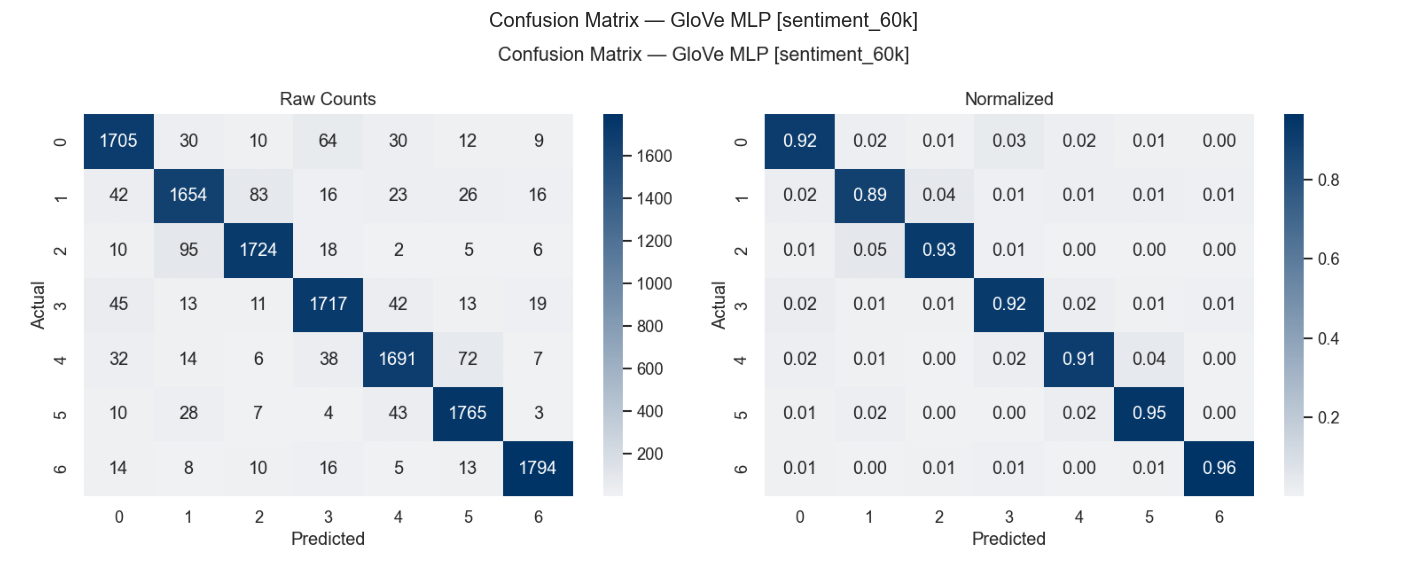

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_mlp_sentiment_60k.png


In [151]:
# ── 5.2.1 Train GloVe MLP ─────────────────────────────────────────
CMAP = sns.light_palette(COLORS[0], as_cmap=True)

deep_curve_rows = []
deep_eval_rows = []
deep_histories = {}
deep_test_preds = {}

for split_key in sentiment_split_keys_dl:
    print()
    print(f"===== GloVe MLP | {split_key} =====")
    split_data = dl_split_data[split_key]

    mlp_model, mlp_history, val_metrics, test_metrics, mlp_preds = run_torch_experiment(
        model_label="GloVe MLP",
        family_slug="glove_mlp",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: EmbeddingMLP(
            embedding_matrix=embedding_matrix,
            num_classes=CFG["num_labels"],
            hidden_dim=256,
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe MLP [{split_key}]"
    deep_histories[run_name] = mlp_history
    deep_test_preds[run_name] = mlp_preds

    deep_curve_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "sentiment_60k":
        plot_confusion_matrix_clf(split_data["y_test"], mlp_preds, run_name, le)



===== GloVe CNN | sentiment_1k =====
GloVe CNN [sentiment_1k]: best checkpoint found -> skip retraining (models/glove_cnn_sentiment_1k_20260313_222724/best_model/best.pt)


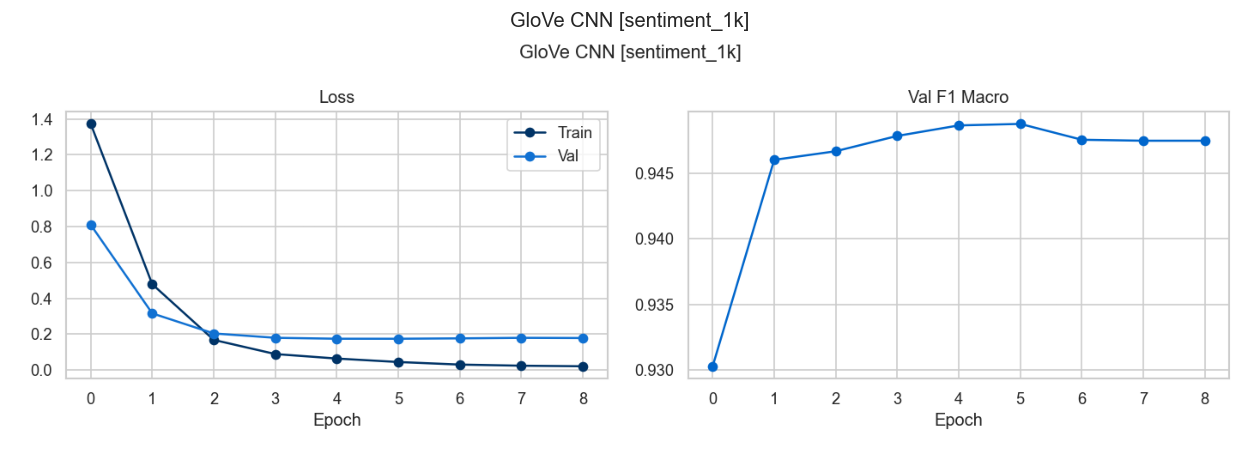

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_sentiment_1k.png

  GloVe CNN [sentiment_1k] | VAL
  Accuracy      : 0.8779
  F1 (macro)    : 0.8792
  F1 (weighted) : 0.8773

              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1860
           1       0.81      0.82      0.81      1860
           2       0.86      0.89      0.87      1860
           3       0.90      0.85      0.88      1860
           4       0.91      0.87      0.89      1860
           5       0.91      0.99      0.95      1860
           6       0.92      0.94      0.93      1409

    accuracy                           0.88     12569
   macro avg       0.88      0.88      0.88     12569
weighted avg       0.88      0.88      0.88     12569

Final validation F1 (macro) [GloVe CNN [sentiment_1k]]: 0.8792


KeyboardInterrupt: 

In [153]:
# ── 5.2.2 Train GloVe CNN ─────────────────────────────────────────
for split_key in sentiment_split_keys_dl:
    print()
    print(f"===== GloVe CNN | {split_key} =====")
    split_data = dl_split_data[split_key]

    cnn_model, cnn_history, val_metrics, test_metrics, cnn_preds = run_torch_experiment(
        model_label="GloVe CNN",
        family_slug="glove_cnn",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: TextCNN(
            embedding_matrix=embedding_matrix,
            num_classes=CFG["num_labels"],
            num_filters=CFG["cnn_num_filters"],
            kernel_sizes=CFG["cnn_kernel_sizes"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe CNN [{split_key}]"
    deep_histories[run_name] = cnn_history
    deep_test_preds[run_name] = cnn_preds

    deep_curve_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "sentiment_60k":
        plot_confusion_matrix_clf(split_data["y_test"], cnn_preds, run_name, le)

---
<a id="section-6-recurrent-models-bilstm-bigru"></a>
# SECTION 6 — Recurrent Models (BiLSTM / BiGRU)

## 6.1 Preparation & Architecture

**BiLSTM with additive attention** — captures long-range dependencies.  
Swap `nn.LSTM` → `nn.GRU` in the constructor for a lighter BiGRU.


In [61]:
# ── 6.1.1 class AdditiveAttention(nn.Module): ─────────────────────────────────────────
class AdditiveAttention(nn.Module):
    """
    Computes a weighted average over LSTM hidden states.
    Weights are learned via a single linear layer + softmax.
    Padding positions are masked out before softmax.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask=None):
        scores = self.attn(h).squeeze(-1)                       
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)                  
        context = (weights.unsqueeze(-1) * h).sum(dim=1)        
        return context, weights


# ── 6.1.2 BiLSTM + Attention ────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    """
    Bidirectional LSTM with additive attention for text classification.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : LSTM hidden state size per direction
    num_layers       : number of stacked LSTM layers
    dropout          : dropout probability
    freeze_emb       : freeze pre-trained embeddings during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AdditiveAttention(hidden_dim * 2)   # *2 for bidirectional
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0)                              # (B, L) True = real token
        emb  = self.dropout(self.embedding(x))       # (B, L, D)
        h, _ = self.lstm(emb)                        # (B, L, 2*H)
        ctx, _ = self.attention(h, mask)             # (B, 2*H)
        return self.fc(self.dropout(ctx))


print("BiLSTMAttention architecture defined.")


BiLSTMAttention architecture defined.


## 6.2 Training


In [62]:
# ── 6.2.1 Train GloVe BiLSTM on the shared split ─────────────────────────────────────────
for split_key in sentiment_split_keys_dl:
    print()
    print(f"===== GloVe BiLSTM | {split_key} =====")
    split_data = dl_split_data[split_key]

    bilstm_model, lstm_history, val_metrics, test_metrics, bilstm_preds = run_torch_experiment(
        model_label="GloVe BiLSTM",
        family_slug="glove_bilstm",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: BiLSTMAttention(
            embedding_matrix=embedding_matrix,
            num_classes=CFG["num_labels"],
            hidden_dim=CFG["lstm_hidden_dim"],
            num_layers=CFG["lstm_num_layers"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe BiLSTM [{split_key}]"
    deep_histories[run_name] = lstm_history
    deep_test_preds[run_name] = bilstm_preds

    deep_curve_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "sentiment_60k":
        plot_confusion_matrix_clf(split_data["y_test"], bilstm_preds, run_name, le)
 


===== GloVe BiLSTM | sentiment_1k =====


KeyboardInterrupt: 

## 6.3 Results


,model,split_key,train_size,f1_macro
0,GloVe CNN,sentiment_1k,1000,0.938333
1,GloVe MLP,sentiment_1k,1000,0.641111
2,GloVe MLP,sentiment_5k,5000,0.836801
3,GloVe MLP,sentiment_10k,10000,0.881502
4,GloVe MLP,sentiment_30k,30000,0.910290
5,GloVe MLP,sentiment_60k,58655,0.916803


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe CNN,sentiment_1k,1000,val,0.938897,0.938333,0.938758,NaN,GloVe CNN [sentiment_1k] | val
1,GloVe MLP,sentiment_1k,1000,val,0.639749,0.641111,0.640490,NaN,GloVe MLP [sentiment_1k] | val
2,GloVe MLP,sentiment_5k,5000,val,0.837298,0.836801,0.836989,NaN,GloVe MLP [sentiment_5k] | val
3,GloVe MLP,sentiment_10k,10000,val,0.881454,0.881502,0.881540,NaN,GloVe MLP [sentiment_10k] | val
4,GloVe MLP,sentiment_30k,30000,val,0.910017,0.910290,0.909775,NaN,GloVe MLP [sentiment_30k] | val
5,GloVe MLP,sentiment_60k,58655,val,0.916143,0.916803,0.916088,NaN,GloVe MLP [sentiment_60k] | val


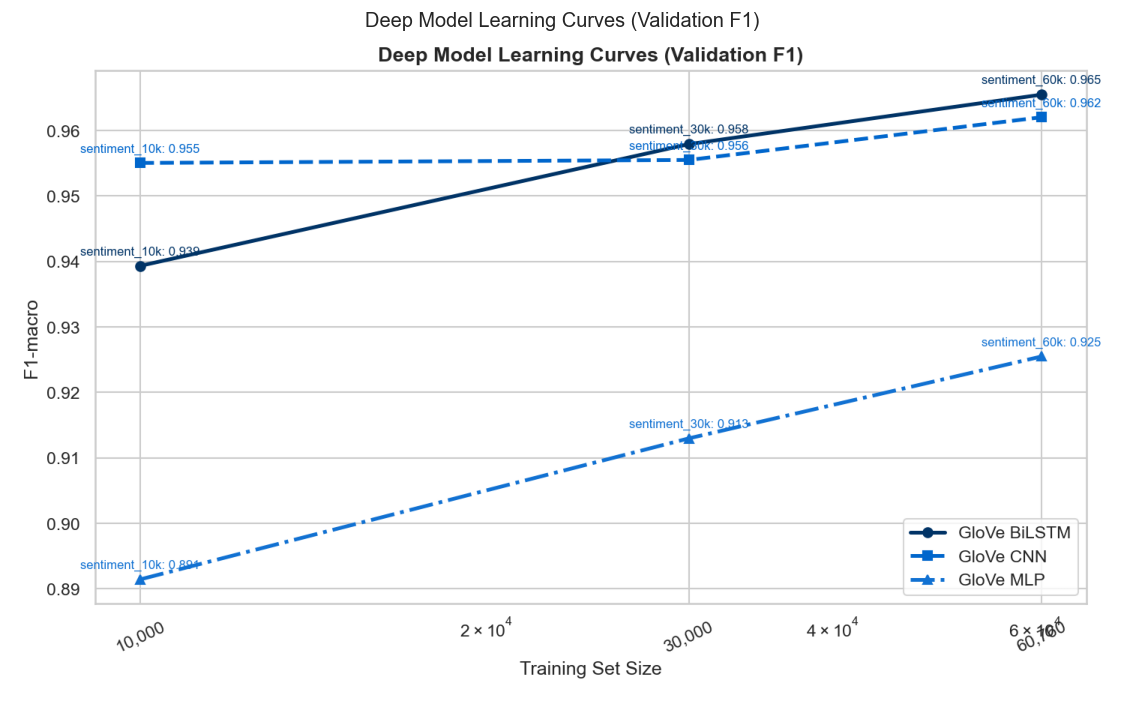

Displayed existing learning curve: outputs/plots/learning_curves/deep_learning_curves_glove_val.png


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
5,GloVe MLP,sentiment_60k,58655,val,0.916143,0.916803,0.916088,NaN,GloVe MLP [sentiment_60k] | val


In [64]:
# ── 6.3.1 Summarize deep-model internal metrics and unified curves ─────────────────────────────────────────
deep_curve_df, deep_eval_df = render_deep_learning_curves_from_results(
    results=RESULTS,
    splits=splits,
    cfg=CFG,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="val",
    title="Deep Model Learning Curves (Validation F1)",
    save_name="deep_learning_curves_glove_val.png",
)

deep_eval_df[deep_eval_df["split_key"] == "sentiment_60k"]

## 6.4 Results For All Models

Loaded csv: outputs\metrics\classical_lc_metrics.csv


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,sentiment_1k,1000,0.687842
1,GloVe BiLSTM,sentiment_5k,5000,0.910552
2,GloVe BiLSTM,sentiment_10k,10000,0.935200
3,GloVe BiLSTM,sentiment_30k,30000,0.954902
4,GloVe BiLSTM,sentiment_60k,60760,0.962078
5,GloVe CNN,sentiment_1k,1000,0.891504
6,GloVe CNN,sentiment_5k,5000,0.949324
7,GloVe CNN,sentiment_10k,10000,0.956151
8,GloVe CNN,sentiment_30k,30000,0.959339
9,GloVe CNN,sentiment_60k,60760,0.962093


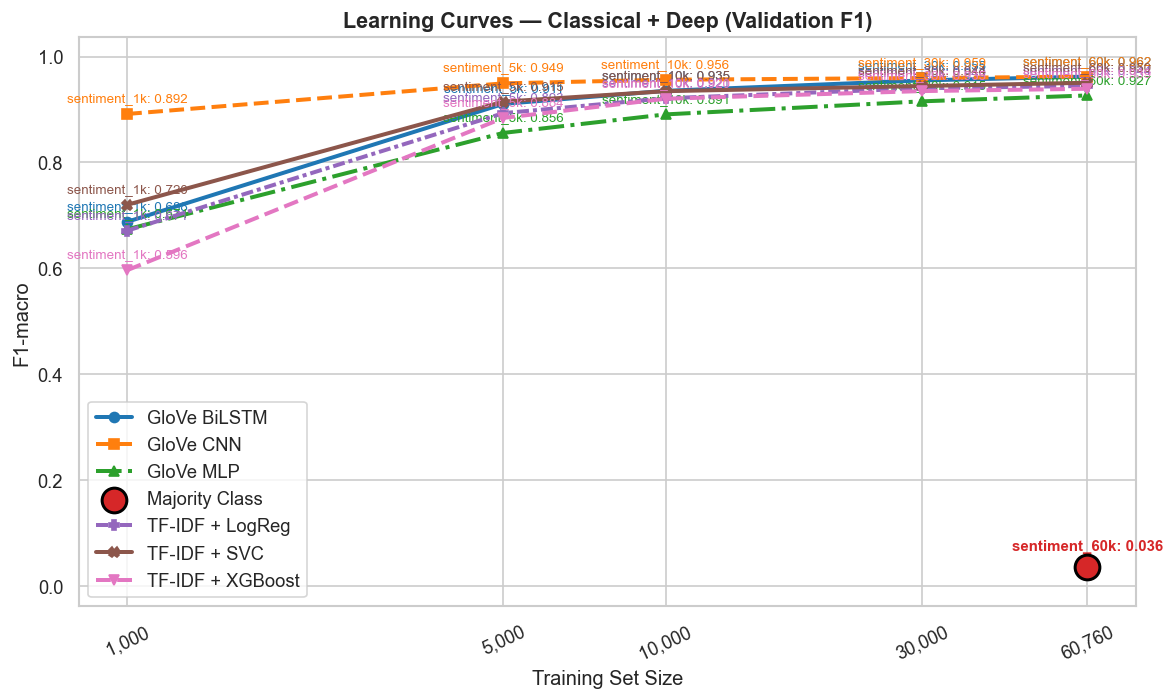

,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,sentiment_1k,1000,0.687842
1,GloVe BiLSTM,sentiment_5k,5000,0.910552
2,GloVe BiLSTM,sentiment_10k,10000,0.935200
3,GloVe BiLSTM,sentiment_30k,30000,0.954902
4,GloVe BiLSTM,sentiment_60k,60760,0.962078
5,GloVe CNN,sentiment_1k,1000,0.891504
6,GloVe CNN,sentiment_5k,5000,0.949324
7,GloVe CNN,sentiment_10k,10000,0.956151
8,GloVe CNN,sentiment_30k,30000,0.959339
9,GloVe CNN,sentiment_60k,60760,0.962093


In [63]:
# ── 6.4.1 Summarize deep-model internal metrics and unified curves ─────────────────────────────────────────
if "deep_curve_df" in globals() and deep_curve_df is not None and not deep_curve_df.empty:
    deep_part = deep_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()
else:
    raise ValueError("deep_curve_df is empty.")

classical_part = load_csv_with_fallback(
    CFG["output_paths"]["metrics"] / "classical_lc_metrics.csv",
    CFG["output_dir"] / "classical_lc_metrics.csv",
)
classical_part = classical_part[["model", "split_key", "train_size", "f1_macro"]].copy()

combined_curve_df = (
    pd.concat([classical_part, deep_part], ignore_index=True)
    .drop_duplicates(subset=["model", "split_key"], keep="last")
    .sort_values(["model", "train_size"])
    .reset_index(drop=True)
)

display(combined_curve_df)

plot_learning_curve_from_metrics(
    combined_curve_df,
    title="Learning Curves — Classical + Deep (Validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "learning_curves_unified_all_models.png",
    force_replot=True,
)


NameError: name 'combined_curve_df' is not defined

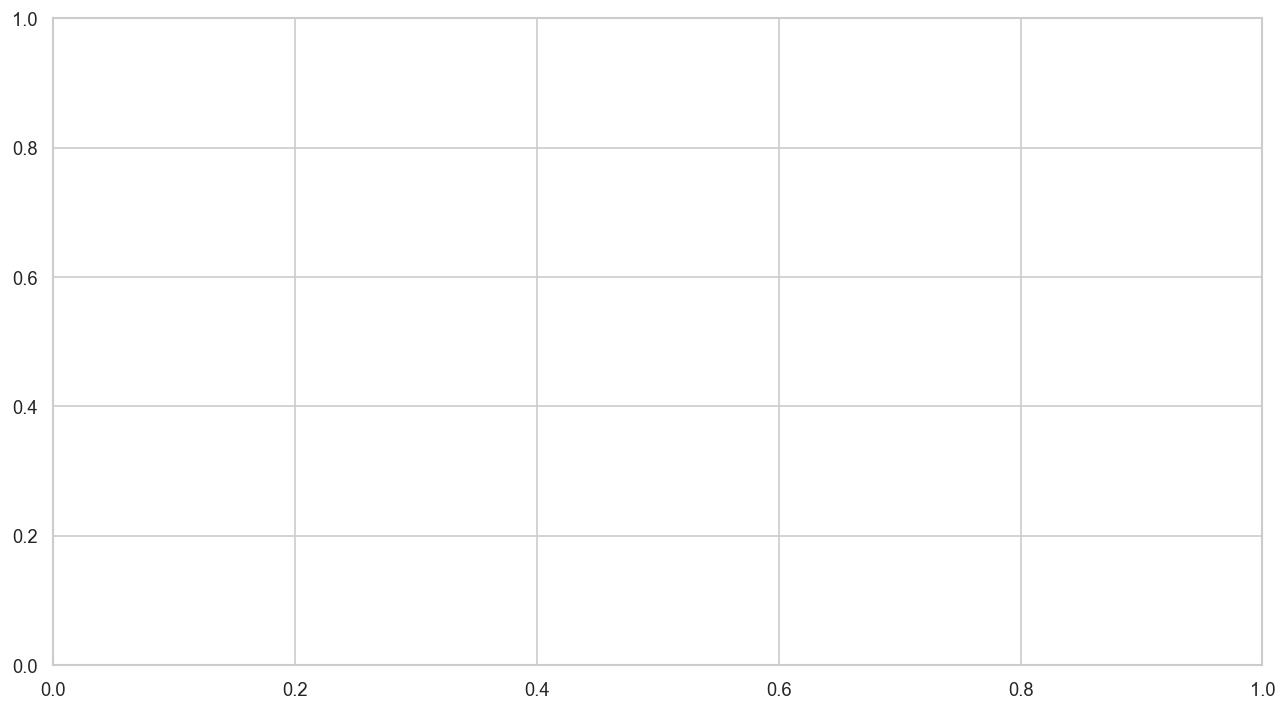

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette("tab10", n_colors=combined_curve_df["model"].nunique())
colors  = dict(zip(combined_curve_df["model"].unique(), palette))

for model_name, group in combined_curve_df.groupby("model"):
    group = group.sort_values("train_size")
    ax.plot(group["train_size"], group["f1_macro"],
            marker="o", label=model_name, color=colors[model_name])
    for _, row in group.iterrows():
        ax.annotate(f"{row['split_key']}: {row['f1_macro']:.3f}",
                    (row["train_size"], row["f1_macro"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.set_xlabel("Training Set Size", fontsize=12)
ax.set_ylabel("F1-macro", fontsize=12)
ax.set_title("Learning Curves — Classical + Deep (Validation F1)", fontsize=13, fontweight="bold")
ax.set_xscale("log")
ax.set_ylim(
    combined_curve_df["f1_macro"].quantile(0.05) - 0.02,
    combined_curve_df["f1_macro"].max() + 0.02
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
save_path_zoom = CFG["output_paths"]["plots_learning"] / "learning_curves_unified_zoom.png"
plt.savefig(save_path_zoom, dpi=120)
plt.show()
print(f"Saved zoomed → {save_path_zoom}")

---
<a id="section-7-transformer-fine-tuning"></a>
# SECTION 7 — Transformer Fine-Tuning

We fine-tune pretrained transformers as our strongest in-domain candidates. We get validation and test summaries for DistilBERT and RoBERTa, and we can pick the best checkpoint for the next transfer checks.

## 7.1 Preparation & Architecture

**Architecture:**

- Fine-tunes pretrained encoder backbones (`distilbert-base-uncased`, `roberta-base`) with the shared transformer training pipeline.
- Uses HuggingFace `Trainer` with early stopping on `f1_macro`.
- Input: `text_raw` (minimally cleaned) — the subword tokenizer handles the rest.

In [154]:
# ── 7.1.1 Prepare transformer bundles and experiment registry ────────────────
TRANSFORMER_RUNS = {}

if "sentiment_60k" not in splits:
    raise ValueError("splits['sentiment_60k'] does not exist. Execute Section 3 first.")

BASE_60K_BUNDLE = build_transformer_bundle_from_split("sentiment_60k")

In [155]:
# ── 7.1.2 Helper: get_small_bundle ───────────────────────────────────────────

from torch.utils.data import Subset
import random

def get_small_bundle(data_bundle, n=1000, seed=42):
    random.seed(seed)
    
    train_size = len(data_bundle["X_train_raw"])
    indices = random.sample(range(train_size), min(n, train_size))
    
    return {
        **data_bundle,
        "X_train_raw": [data_bundle["X_train_raw"][i] for i in indices],
        "y_train":     [data_bundle["y_train"][i] for i in indices],
        "name":        data_bundle["name"] + f"_small{n}",
    }

SMALL_BUNDLE = get_small_bundle(BASE_60K_BUNDLE, n=1000)

print(f"Train size: {len(SMALL_BUNDLE['X_train_raw'])}")
print(f"Labels size: {len(SMALL_BUNDLE['y_train'])}")

Train size: 1000
Labels size: 1000


## 7.2 Training

### 7.2.1 DistilBERT_60k


### 7.2.1 DistilBERT_60k ###
DistilBERT_60k: best model already exists -> skip retraining (models/distilbert_sentiment_60k_20260313_194030/best_model)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT_60k | VAL
  Accuracy      : 0.9730
  F1 (macro)    : 0.9737
  F1 (weighted) : 0.9730

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1860
           1       0.99      0.95      0.97      1860
           2       0.96      1.00      0.98      1860
           3       0.98      0.96      0.97      1860
           4       0.97      0.93      0.95      1860
           5       0.95      1.00      0.97      1860
           6       1.00      1.00      1.00      1409

    accuracy                           0.97     12569
   macro avg       0.97      0.97      0.97     12569
weighted avg       0.97      0.97      0.97     12569


  DistilBERT_60k | TEST
  Accuracy      : 0.9748
  F1 (macro)    : 0.9755
  F1 (weighted) : 0.9747

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1860
           1       0.99      0.95      0.97      1860
           2       0.96      1.00      

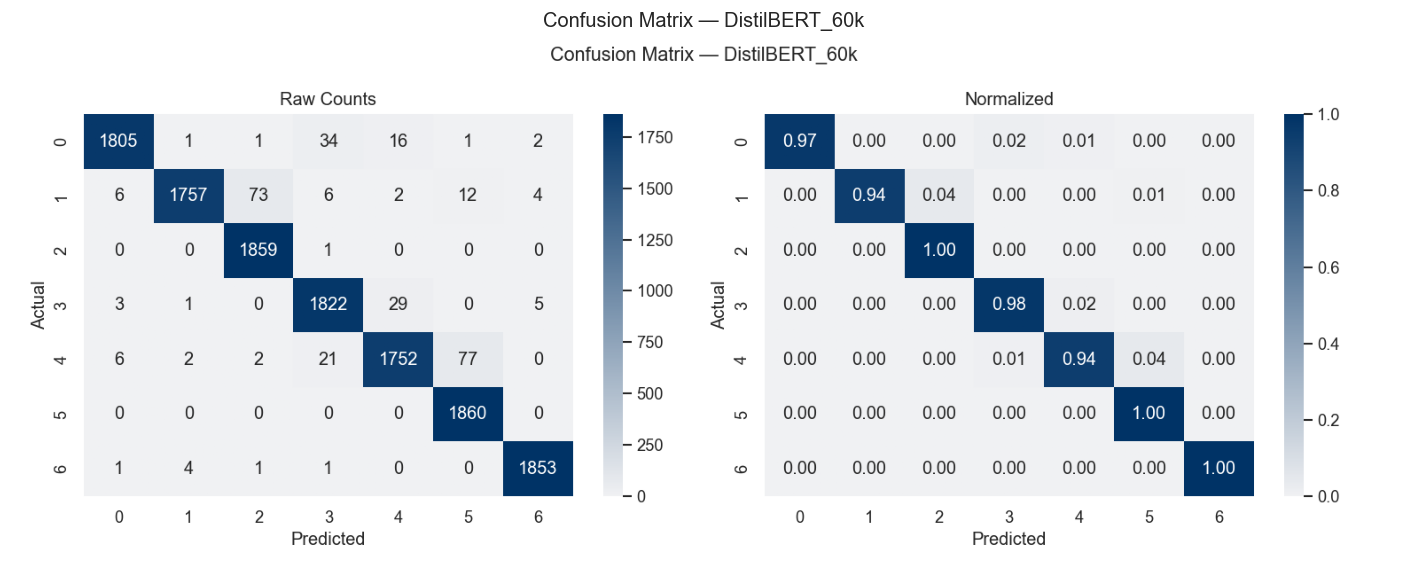

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_60k.png


In [156]:
# ── 7.2.1 DistilBERT_60k ─────────────────────────────────────────
print("\n### 7.2.1 DistilBERT_60k ###")

TRANSFORMER_RUNS["DistilBERT_60k"] = run_transformer_experiment(
    display_name="DistilBERT_60k",
    family_slug="distilbert",
    size_tag="60k",
    model_name="distilbert-base-uncased",
    data_bundle=BASE_60K_BUNDLE,
    batch_size=8,
    epochs=3,
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    early_stopping_patience=2,
    eval_mode="epoch",
    legacy_best_dirs=[],
    legacy_checkpoint_dirs=[],
)

### 7.2.2 RoBERTa_60k


### 11.2.2 RoBERTa_60k ###
RoBERTa_60k: best model already exists -> skip retraining (models\roberta_base_sentiment_60k_20260308_223331\best_model)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  RoBERTa_60k | VAL
  Accuracy      : 0.9750
  F1 (macro)    : 0.9749
  F1 (weighted) : 0.9749

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1860
           1       0.99      0.96      0.97      1860
           2       0.96      1.00      0.98      1860
           3       0.98      0.97      0.97      1860
           4       0.96      0.94      0.95      1860
           5       0.94      1.00      0.97      1860
           6       1.00      1.00      1.00      1860

    accuracy                           0.97     13020
   macro avg       0.98      0.97      0.97     13020
weighted avg       0.98      0.97      0.97     13020


  RoBERTa_60k | TEST
  Accuracy      : 0.9758
  F1 (macro)    : 0.9758
  F1 (weighted) : 0.9758

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1860
           1       0.99      0.94      0.97      1860
           2       0.96      1.00      0.98  

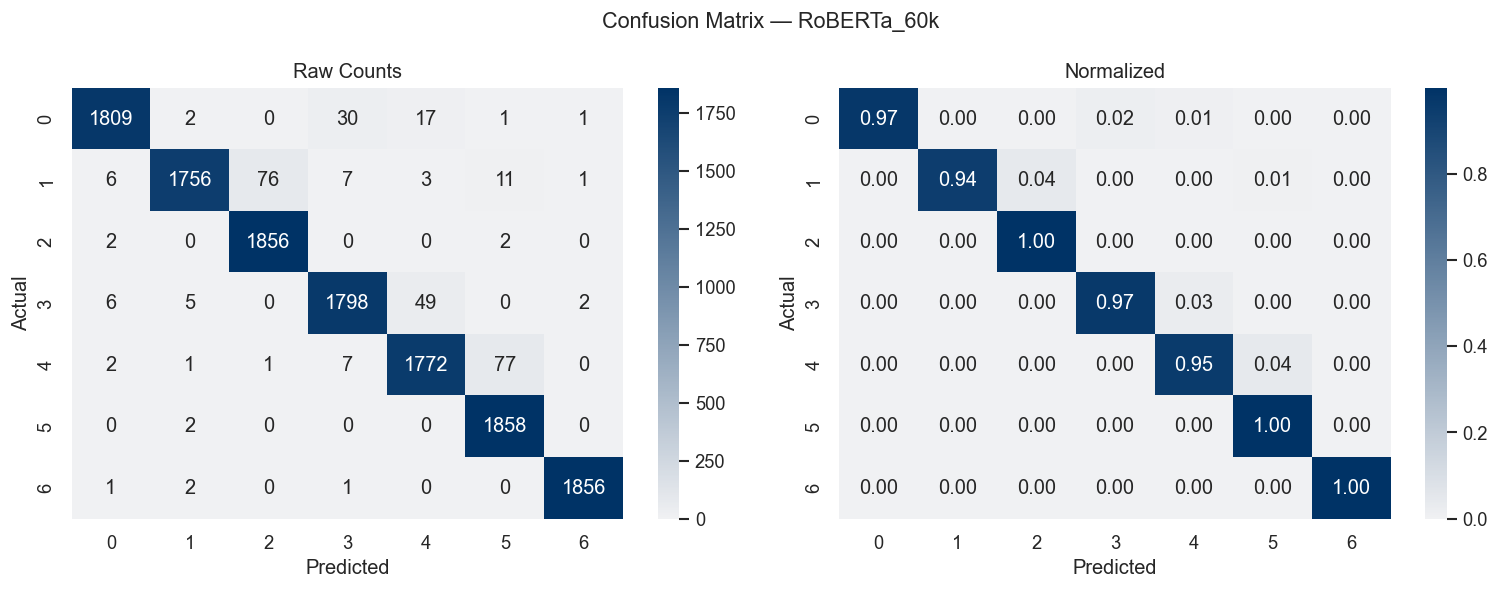

In [68]:
# ── 7.2.2 RoBERTa_60k ─────────────────────────────────────────
# Note: RoBERTa_60k can be marginally better, but usually not worth the extra compute cost.
print("\n### 7.2.2 RoBERTa_60k ###")

TRANSFORMER_RUNS["RoBERTa_60k"] = run_transformer_experiment(
    display_name="RoBERTa_60k",
    family_slug="roberta_base",
    size_tag="60k",
    model_name="roberta-base",
    data_bundle=BASE_60K_BUNDLE,
    batch_size=16,                     
    epochs=2,                          
    lr=2e-5,
    warmup_ratio=0.03,                 
    weight_decay=0.01,
    gradient_accumulation_steps=1,     
    early_stopping_patience=1,         
    eval_mode="epoch",
    legacy_best_dirs=[
        CFG["model_dir"] / "roberta_base_60k_best",
    ],
    legacy_checkpoint_dirs=[
        CFG["model_dir"] / "roberta_base_60k",
    ],
)

## 7.3 Results

In [69]:
# ── 11.6 transformer_summary_rows = [] ─────────────────────────────────────────
transformer_summary_rows = []
for name in ["DistilBERT_60k", "RoBERTa_60k"]:
    run = TRANSFORMER_RUNS[name]
    transformer_summary_rows.append({
        "experiment": name,
        "val_f1_macro": float(run["val_metrics"]["f1_macro"]),
        "test_f1_macro": float(run["test_metrics"]["f1_macro"]),
        "best_model": str(run["best_dir"]),
    })

transformer_summary_df = pd.DataFrame(transformer_summary_rows).sort_values("val_f1_macro", ascending=False)
display(transformer_summary_df)

for row in transformer_summary_df.itertuples(index=False):

    size_tag = "60k" if "60k" in row.experiment else "1000k"
    
    RESULTS[f"LC | {row.experiment} | sentiment_{size_tag}"] = {
        "f1_macro": float(row.val_f1_macro)
    }

,experiment,val_f1_macro,test_f1_macro,best_model
0,DistilBERT_60k,0.975430,0.975965,models\distilbert_sentiment_60k_20260308_13412...
1,RoBERTa_60k,0.974931,0.975763,models\roberta_base_sentiment_60k_20260308_223...


---
<a id="section-8-model-comparison-results-table"></a>
# SECTION 8 — Model Comparison & Results Table


We collect everything in one place for a final comparison. We get the consolidated table, comparison plots, and a small error sample, and we can read the ranking at a glance before writing the full report.

In [173]:
# -- 8.1 Save artefacts -----------------------------------------------------
if not RESULTS:
    restored_results_count = restore_results_from_saved_artifacts(
        CFG,
        reset=True,
        include_eval=True,
        include_learning_curves=True,
    )
    print(f"RESULTS restored from saved artifacts: {restored_results_count}")

save_artefacts()

Artefacts saved  ->  outputs/metrics  |  models/shared


In [174]:
# -- 8.2 Build and persist the consolidated results table -------------------
if not RESULTS:
    restore_results_from_saved_artifacts(
        CFG,
        reset=True,
        include_eval=True,
        include_learning_curves=True,
    )

if RESULTS:
    df_results = (
        pd.DataFrame(RESULTS)
        .T
        .rename_axis("Model | Split")
        .reset_index()
    )
    df_results[["model_name", "metric_split"]] = df_results["Model | Split"].str.rsplit(" | ", n=1, expand=True)
    df_results = df_results.sort_values(["metric_split", "f1_macro"], ascending=[True, False]).reset_index(drop=True)
else:
    df_results = load_saved_results_df(CFG)

if df_results.empty:
    print("No results available. Run earlier sections or ensure saved result artifacts exist.")
else:
    display(df_results.round(4))

    metrics_dir = CFG["output_paths"]["metrics"]
    joblib.dump(df_results, metrics_dir / f"results_{CFG['task']}.pkl")
    print("Results saved.")

    internal_test_leaderboard_df = (
        df_results[
            (df_results["metric_split"] == "test") &
            (~df_results["model_name"].str.startswith("LC |"))
        ]
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )
    display(internal_test_leaderboard_df.head(15).round(4))
    internal_test_leaderboard_df.to_csv(metrics_dir / "internal_test_leaderboard.csv", index=False)
    joblib.dump(internal_test_leaderboard_df, metrics_dir / "internal_test_leaderboard.pkl")

,Model | Split,accuracy,f1_macro,f1_weighted,model_name,metric_split
0,LC | TF-IDF + SVC | sentiment_10k,NaN,0.9316,NaN,LC | TF-IDF + SVC,sentiment_10k
1,LC | TF-IDF + LogReg | sentiment_10k,NaN,0.9204,NaN,LC | TF-IDF + LogReg,sentiment_10k
2,LC | TF-IDF + XGBoost | sentiment_10k,NaN,0.9193,NaN,LC | TF-IDF + XGBoost,sentiment_10k
3,LC | TF-IDF + SVC | sentiment_1k,NaN,0.7002,NaN,LC | TF-IDF + SVC,sentiment_1k
4,LC | TF-IDF + LogReg | sentiment_1k,NaN,0.6629,NaN,LC | TF-IDF + LogReg,sentiment_1k
...,...,...,...,...,...,...
56,TF-IDF + SVC [sentiment_1k] | val,0.7009,0.7002,0.6962,TF-IDF + SVC [sentiment_1k],val
57,TF-IDF + LogReg [sentiment_1k] | val,0.6619,0.6629,0.6577,TF-IDF + LogReg [sentiment_1k],val
58,GloVe MLP [sentiment_1k] | val,0.6397,0.6411,0.6405,GloVe MLP [sentiment_1k],val
59,TF-IDF + XGBoost [sentiment_1k] | val,0.6078,0.6159,0.6104,TF-IDF + XGBoost [sentiment_1k],val


Results saved.


,Model | Split,accuracy,f1_macro,f1_weighted,model_name,metric_split
0,DistilBERT_60k | test,0.9748,0.9755,0.9747,DistilBERT_60k,test
1,TF-IDF + SVC [sentiment_60k] | test,0.9492,0.9496,0.9491,TF-IDF + SVC [sentiment_60k],test
2,TF-IDF + SVC [sentiment_30k] | test,0.9469,0.9471,0.9467,TF-IDF + SVC [sentiment_30k],test
3,TF-IDF + LogReg [sentiment_60k] | test,0.9449,0.9450,0.9447,TF-IDF + LogReg [sentiment_60k],test
4,TF-IDF + LogReg [sentiment_30k] | test,0.9402,0.9402,0.9399,TF-IDF + LogReg [sentiment_30k],test
5,TF-IDF + XGBoost [sentiment_60k] | test,0.9381,0.9385,0.9378,TF-IDF + XGBoost [sentiment_60k],test
6,TF-IDF + SVC [sentiment_10k] | test,0.9352,0.9355,0.9349,TF-IDF + SVC [sentiment_10k],test
7,TF-IDF + XGBoost [sentiment_30k] | test,0.9344,0.9348,0.9341,TF-IDF + XGBoost [sentiment_30k],test
8,TF-IDF + LogReg [sentiment_10k] | test,0.9223,0.9224,0.9218,TF-IDF + LogReg [sentiment_10k],test
9,GloVe MLP [sentiment_60k] | test,0.9179,0.9186,0.9178,GloVe MLP [sentiment_60k],test


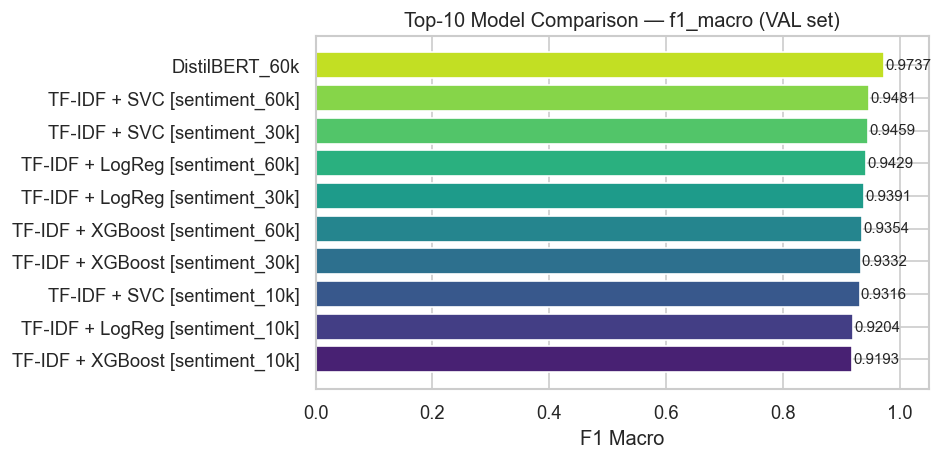

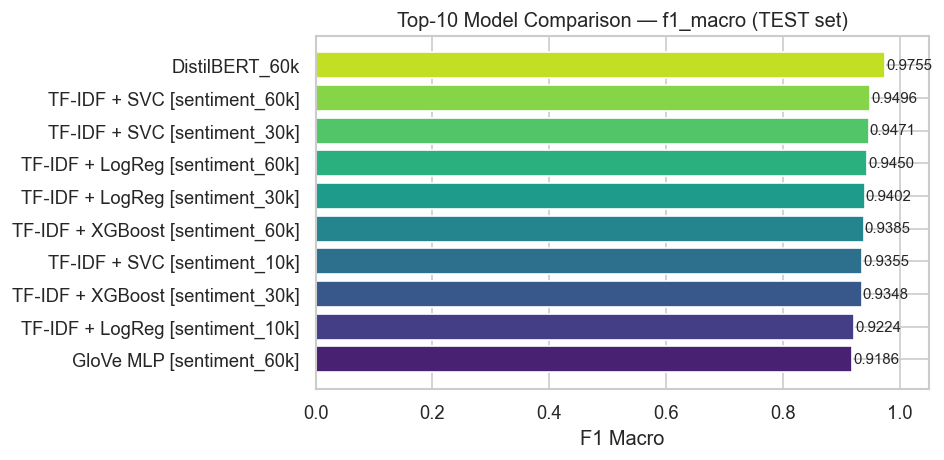

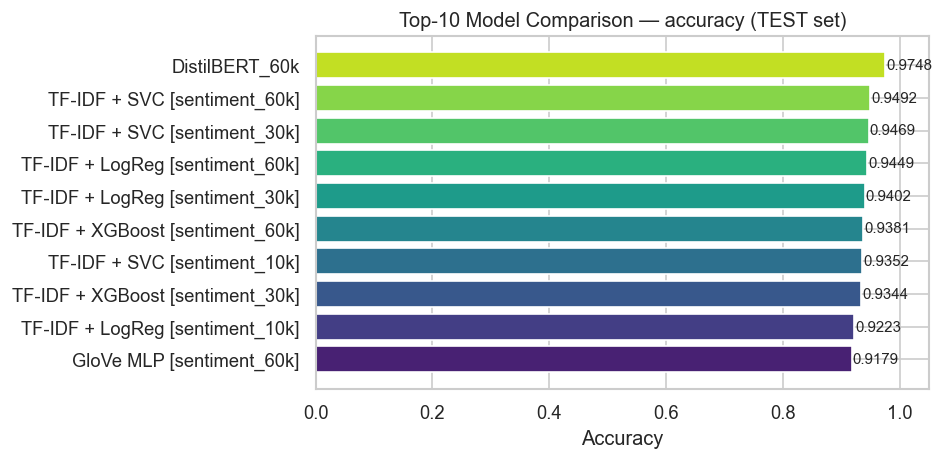

In [175]:
# -- 8.3 Visualization of best models ---------------------------
top10_val_f1_df = get_top_models_df(RESULTS, split="val", metric="f1_macro", top_n=10)
top10_test_f1_df = get_top_models_df(RESULTS, split="test", metric="f1_macro", top_n=10)
top10_test_acc_df = get_top_models_df(RESULTS, split="test", metric="accuracy", top_n=10)

metrics_dir = CFG["output_paths"]["metrics"]
if not top10_val_f1_df.empty:
    top10_val_f1_df.to_csv(metrics_dir / "top10_val_f1_macro.csv", index=False)
if not top10_test_f1_df.empty:
    top10_test_f1_df.to_csv(metrics_dir / "top10_test_f1_macro.csv", index=False)
if not top10_test_acc_df.empty:
    top10_test_acc_df.to_csv(metrics_dir / "top10_test_accuracy.csv", index=False)

plot_top_model_comparison(RESULTS, metric="f1_macro", split="val", top_n=10)
plot_top_model_comparison(RESULTS, metric="f1_macro", split="test", top_n=10)
plot_top_model_comparison(RESULTS, metric="accuracy", split="test", top_n=10);

## 8.1 Final Transformer 

In [184]:
# ── 8.1.1 Final/default transformer artefacts for downstream cells ─────────────────────────────────────────
FINAL_TRANSFORMER_NAME = "DistilBERT_60k"
FINAL_TRANSFORMER_RUN = TRANSFORMER_RUNS[FINAL_TRANSFORMER_NAME]
TRANSFORMER_FINAL_BEST_PATH = FINAL_TRANSFORMER_RUN["best_dir"]

trf_test_preds = FINAL_TRANSFORMER_RUN["test_preds"]
trf_val_preds = FINAL_TRANSFORMER_RUN["val_preds"]
trf_y_test = FINAL_TRANSFORMER_RUN["y_test"]
trf_df_test = FINAL_TRANSFORMER_RUN["df_test"]

print(f"Final transformer: {FINAL_TRANSFORMER_NAME} -> {TRANSFORMER_FINAL_BEST_PATH}")

Final transformer: DistilBERT_60k -> models/distilbert_sentiment_60k_20260313_194030/best_model


In [191]:
print(type(error_df["true_label"].iloc[0]))
print(error_df["true_label"].iloc[0])

<class 'float'>
nan


In [192]:
# ── 8.1.2 Error analysis for the final transformer ─────────────────────────────────────────
print(f"=== Error Analysis — {FINAL_TRANSFORMER_NAME} ===")

y_true = np.asarray(trf_y_test)
y_pred = np.asarray(trf_test_preds)

err_mask = y_true != y_pred
texts = np.asarray(trf_df_test[CFG["text_col"]])

error_df = pd.DataFrame({
    "text": texts[err_mask],
    "true_label": [LABEL_NAMES[i] for i in y_true[err_mask]],
    "pred_label": [LABEL_NAMES[i] for i in y_pred[err_mask]],
}).head(10)

display(error_df)

=== Error Analysis — DistilBERT_60k ===


,text,true_label,pred_label
0,i feel this post will be all over the place therefore im going for one of my beloved lists,joy,love
1,i was beginning to feel overwhelmed any necessity to follow the book,fear,surprise
2,my daughter was yrs she went up to a colt tried to hit it it turned on her and kicked her over the heart,fear,anger
3,i feel like he puts no effort in being considerate for me,joy,love
4,i do not like being called a prayer warrior because it makes me feel like rambo or something but i do want to be faithful in what the lord has called me to do in this season of my life,joy,love
5,i want to fit in and feel accepted,joy,love
6,id say part of that decision is down to the wonderful pr behind the launch and also the packaging which has a slight feel of my beloved eve lom to it,joy,love
7,i feel like fantasy writers have this thing about hating things that are popular and widespread,joy,love
8,i allowed to feel stressed out,sadness,anger
9,i came back an extended time i was definitely feeling stressed but my manager set her expectations fairly which enabled me to ramp up very quickly and continue where i left off,anger,sadness


Let us analyse which classes the model confuses the most. The most frequent errors occur between semantically adjacent emotions: **fear → surprise** (99 cases) and **joy → love** (73 cases), while negative emotions — sadness, anger, and fear — show mutual confusion, reflecting their shared tense tone.

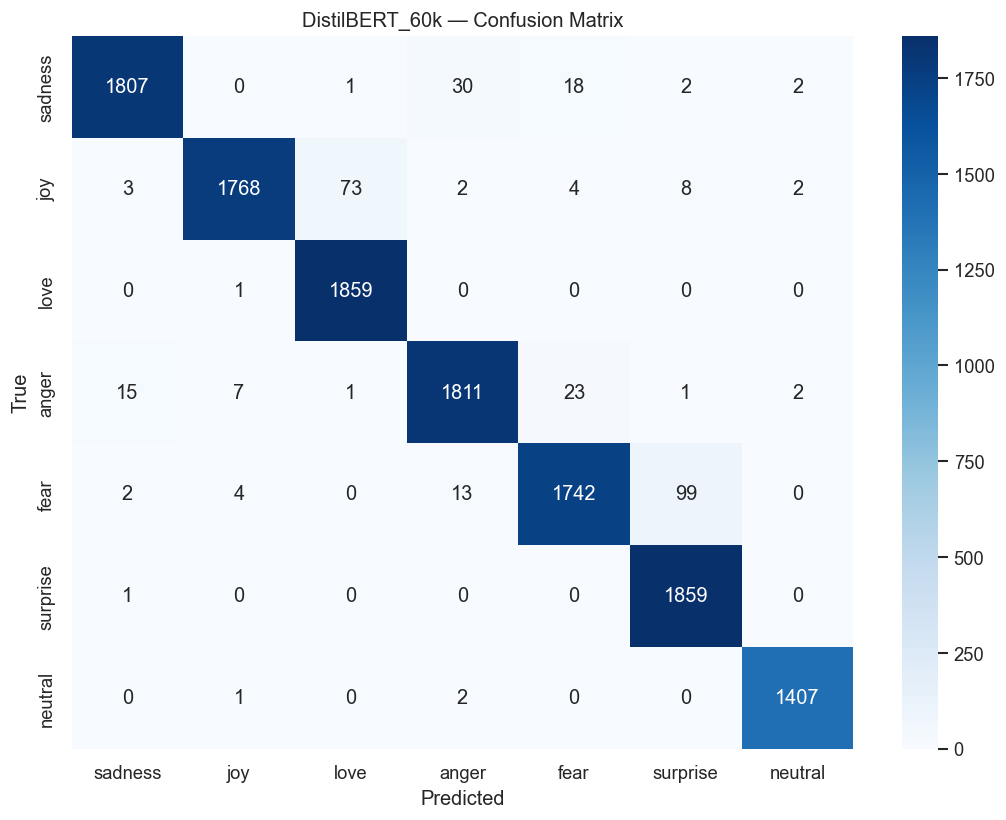

,true,predicted,count
0,fear,surprise,99
1,joy,love,73
2,sadness,anger,30
3,anger,fear,23
4,sadness,fear,18
5,anger,sadness,15
6,fear,anger,13
7,joy,surprise,8
8,anger,joy,7
9,fear,joy,4


In [193]:
# ── 8.1.3 Confusion Matrix ─────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

label_order = list(LABEL_NAMES.values())

cm = confusion_matrix(trf_y_test, trf_test_preds)
cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("DistilBERT_60k — Confusion Matrix")
plt.tight_layout()
plt.show()

errors = []
for i in range(len(label_order)):
    for j in range(len(label_order)):
        if i != j and cm[i, j] > 0:
            errors.append({
                "true": label_order[i],
                "predicted": label_order[j],
                "count": cm[i, j]
            })

errors_df = pd.DataFrame(errors).sort_values("count", ascending=False).head(10).reset_index(drop=True)
display(errors_df)

We can see how predictions of the best model works in the section below.

In [208]:
# ── 8.1.4 Load best model and predict ────────────────────────────
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

MODEL_PATH = str(FINAL_TRANSFORMER_RUN["best_dir"])

trf_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
trf_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, local_files_only=True)
trf_model.to(torch.device(CFG["device"]))
trf_model.eval()

@torch.no_grad()
def predict_one(text: str):
    inputs = trf_tokenizer(
        text, return_tensors="pt", truncation=True,
        padding=True, max_length=CFG.get("max_len", 256)
    ).to(torch.device(CFG["device"]))
    logits = trf_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)
    conf, pred_id = torch.max(probs, dim=-1)
    return LABEL_NAMES[int(pred_id)], float(conf)

# ── Quick manual check ────────────────────────────────────────────
example_texts = [
    "I am feeling absolutely wonderful today!",   # Joy
    "I really love you.",   # Anger
    "I'm not sure how I feel about this.",        # Neutral
    "I am terrified of what might happen next.",  # Fear
]

for i, text in enumerate(example_texts, start=1):
    label, conf = predict_one(text)
    print(f"{i}. {text}")
    print(f"   → {label} ({conf:.4f})")
    print("-" * 80)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

1. I am feeling absolutely wonderful today!
   → joy (0.9984)
--------------------------------------------------------------------------------
2. I really love you.
   → neutral (1.0000)
--------------------------------------------------------------------------------
3. I'm not sure how I feel about this.
   → neutral (1.0000)
--------------------------------------------------------------------------------
4. I am terrified of what might happen next.
   → neutral (0.9999)
--------------------------------------------------------------------------------


---
<a id="section-9-saving-logging-final-report"></a>
# SECTION 9 — Saving, Logging & Final Report


In [79]:
# ── 9.1 def save_artefacts(): ─────────────────────────────────────────
def save_artefacts():
    """Saves CFG, RESULTS, label encoder and vocab to disk."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    metrics_dir = CFG["output_paths"]["metrics"]
    metrics_dir.mkdir(parents=True, exist_ok=True)

    cfg_serializable = {k: str(v) if isinstance(v, Path) else v
                        for k, v in CFG.items()}
    with open(metrics_dir / f"cfg_{timestamp}.json", "w") as f:
        json.dump(cfg_serializable, f, indent=2, default=str)

    with open(metrics_dir / f"results_{timestamp}.json", "w") as f:
        json.dump(RESULTS, f, indent=2)

    shared_model_dir = CFG["model_dir"] / "shared"
    shared_model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(le, shared_model_dir / "label_encoder.pkl")
    joblib.dump(vocab, shared_model_dir / "vocab.pkl")

    print(f"Artefacts saved  ->  {metrics_dir}  |  {shared_model_dir}")

save_artefacts()


Artefacts saved  ->  outputs\metrics  |  models\shared
